# El contrato de la web

### Qué botones y selectores hay que poner, y qué devuelve el motor

Este notebook es **dos cosas a la vez**, y esa es la idea:

1. **La especificación que implementa la web.** Cada campo del formulario, con su control, su
   tipo, su valor por defecto, su validación y la columna exacta donde acaba.
2. **La comprobación en vivo contra el servidor.** El mismo documento arma un formulario de
   ejemplo, lo valida, lo manda y enseña lo que vuelve.

Las dos salen de **una sola fuente**: el diccionario `CAMPOS` de la sección 2. Si mañana se
añade un campo al motor, se añade ahí y la tabla de la web, el validador y la comprobación se
actualizan solos. Una especificación que se puede ejecutar no se queda desfasada en silencio,
que es lo que le pasa a un documento de Word con la lista de campos.

---

### De qué se ocupa cada uno

**El motor ya está montado y corriendo.** La curva de precios a veinte años se republica sola
cada día a las 11:45 y vive en `app_curve` + `app_curve_hourly`. El usuario de la web **no la
pide, no la elige y no la ve**: está ahí.

**La web pide tres cosas**, y solo tres:

| | qué sube el usuario | a dónde va |
|---|---|---|
| 🔌 | la **curva de consumo** — un Excel o un CSV horario | `app_consump_inst` + `app_consump_shape` |
| ☀️ | la **curva de generación** — otro Excel o CSV, o nada si no hay | `app_gen_inst` + `app_gen_shape` |
| 🔋 | la **ficha de la batería** — un formulario de números | `app_battery_model` |

**El motor devuelve dos bloques:** el despacho óptimo hora a hora y las cifras económicas
—margen, ciclos, VAN, cobertura del CAPEX— con su banda de incertidumbre.

In [1]:
from __future__ import annotations
import sys, json, os
from pathlib import Path
from datetime import date, timedelta

import numpy as np
import pandas as pd

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
for sub in ("production/app", "production/curva", "scripts"):
    sys.path.insert(0, str(REPO / sub))

os.environ.setdefault("TFM_EMAIL", "acjg.sgs@outlook.com")
pd.set_option("display.width", 200, "display.max_columns", 50,
              "display.max_colwidth", 60)
print(f"  repo   {REPO}")
print(f"  hoy    {date.today()}")

  repo   C:\Users\torgi\proyectos\tfm-energia
  hoy    2026-08-31


---
## 1 · Lo que ya está puesto y la web no tiene que pedir

Antes de hablar del formulario conviene ver qué hay al otro lado, porque determina qué **no**
hace falta preguntar al usuario.

In [2]:
from caso import conexion

con = conexion()
cur = con.cursor()

cur.execute("SELECT generated_at, last_observed_date, date_from, date_to, "
            "n_scenarios, n_hours, engine, matrix_name, matrix_hash FROM app_curve")
c = cur.fetchone()

if c is None:
    print("  NO HAY CURVA PUBLICADA -- la web no puede optimizar nada")
else:
    gen, obs, d0, d1, ns, nh, motor, mtz, mh = c
    print(f"  curva publicada el {gen:%Y-%m-%d %H:%M} · motor '{motor}'")
    print(f"  matriz '{mtz}' hash {mh} · dato real hasta {obs}")
    print(f"  {d0} -> {d1} · {ns} escenarios x {nh:,} horas")
    print()
    cur.execute("SELECT count(*), min(datetime), max(datetime) FROM app_curve_hourly")
    n, a, b = cur.fetchone()
    print(f"  percentiles horarios: {n:,} filas · {a:%Y-%m-%d} -> {b:%Y-%m-%d}")
    print()
    print(f"  El usuario NO elige curva: hay UNA, se pisa cada dia a las 11:45.")
    print(f"  La web puede enseñarla, pero no es un campo del formulario.")

  curva publicada el 2026-08-31 22:55 · motor 'fundamental'
  matriz 'produccion' hash d14b7cb4 · dato real hasta 2026-09-01
  2026-09-02 -> 2046-12-31 · 10 escenarios x 178,224 horas

  percentiles horarios: 178,224 filas · 2026-09-02 -> 2046-12-31

  El usuario NO elige curva: hay UNA, se pisa cada dia a las 11:45.
  La web puede enseñarla, pero no es un campo del formulario.


De dónde sale el precio de cada día, que es la otra cosa que la web no pregunta. El motor lo
pega solo, de tres fuentes, por fecha:

| tramo | fuente | qué es |
|---|---|---|
| hasta ayer | `spot_price` | el precio que **fue**. Una sola realización, sin banda |
| mañana | `predictions` | el **ensemble de once modelos**, publicado a las 11:30 |
| de pasado mañana en adelante | `app_curve_hourly` | los escenarios de la curva, con su banda |

Por eso un caso puede empezar en el pasado: sirve para contrastar el motor contra lo que
realmente pasó antes de creerse lo que dice del futuro.

In [3]:
frontera = date.today() + timedelta(days=1)
print(f"  hasta {date.today() - timedelta(days=1)}   spot_price        precio realizado")
print(f"  el    {frontera}   predictions       ensemble de 11 modelos")
print(f"  desde {frontera + timedelta(days=1)}   app_curve_hourly  {ns} escenarios\n")

if d0 > frontera + timedelta(days=1):
    print(f"  AVISO: la curva empieza el {d0} y quedan dias sin precio.")
else:
    print(f"  Sin huecos: las tres fuentes encajan.")

  hasta 2026-08-30   spot_price        precio realizado
  el    2026-09-01   predictions       ensemble de 11 modelos
  desde 2026-09-02   app_curve_hourly  10 escenarios

  Sin huecos: las tres fuentes encajan.


---
## 2 · El formulario, campo por campo

**Esta es la sección para Magui.** Cada fila es un control de la web.

La columna `control` dice qué poner: `número`, `selector`, `fichero`, `fecha`, `interruptor`.
La columna `destino` dice en qué columna de qué tabla acaba, que es lo que necesita el
`INSERT`. Los campos marcados como no obligatorios **pueden no aparecer en la pantalla
principal**: tienen un valor por defecto sensato y caben en un desplegable de *opciones
avanzadas*.

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
#  LA FUENTE UNICA. De aqui salen la tabla para la web, el validador y la
#  comprobacion contra el servidor. Un campo nuevo se añade UNA vez.
#
#  pantalla  en que bloque del formulario va
#  control   que widget hay que poner
#  ui        como se le enseña al usuario (unidad de pantalla)
#  factor    multiplicador de la unidad de pantalla a la unidad de la base
#  destino   tabla.columna donde acaba
# ══════════════════════════════════════════════════════════════════════════════

def C(pantalla, campo, control, destino, obligatorio=False, defecto=None,
      ui=None, factor=1.0, rango=None, opciones=None, nota=""):
    return dict(pantalla=pantalla, campo=campo, control=control, destino=destino,
                obligatorio=obligatorio, defecto=defecto, ui=ui, factor=factor,
                rango=rango, opciones=opciones, nota=nota)


CAMPOS = [
    # ── 🔋 la bateria ─────────────────────────────────────────────────────────
    C("bateria", "code", "texto", "app_battery_model.code", True,
      nota="identificador corto, unico por usuario"),
    C("bateria", "name", "texto", "app_battery_model.name", True),
    C("bateria", "potencia", "numero", "app_battery_model.power_mw", True,
      ui="kW", factor=0.001, rango=(5, 100_000),
      nota="la NOMINAL del inversor; todo lo demas va en % de ella"),
    C("bateria", "duracion", "selector", "app_battery_model.duration_h", True,
      defecto=4, opciones=[1, 2, 4, 6, 8], ui="h",
      nota="energia = potencia x duracion; 4 h es el estandar de mercado"),
    C("bateria", "carga_max", "numero", "app_battery_model.charge_max_pct",
      defecto=100, ui="% de la nominal", rango=(10, 100),
      nota="muchos equipos cargan mas despacio de lo que descargan"),
    C("bateria", "descarga_max", "numero", "app_battery_model.discharge_max_pct",
      defecto=100, ui="% de la nominal", rango=(10, 100)),
    C("bateria", "potencia_minima", "numero", "app_battery_model.power_min_pct",
      defecto=0, ui="% de la nominal", rango=(0, 50),
      nota="AVISAR: por encima de 0 el problema pasa de LP a MILP y tarda 20-40x"),
    C("bateria", "eficiencia", "numero", "app_battery_model.efficiency_rt",
      defecto=0.90, ui="ida y vuelta, 0-1", rango=(0.70, 0.99),
      nota="se reparte en dos raices: una al cargar y otra al descargar"),
    C("bateria", "soc_min", "numero", "app_battery_model.soc_min",
      defecto=0.05, rango=(0.0, 0.30)),
    C("bateria", "soc_max", "numero", "app_battery_model.soc_max",
      defecto=0.95, rango=(0.70, 1.0)),
    C("bateria", "ciclos_vida", "numero", "app_battery_model.cycle_life",
      defecto=6000, rango=(1000, 15000), nota="a la profundidad de descarga nominal"),
    C("bateria", "degradacion_1000", "numero", "app_battery_model.degradation_per_1000",
      defecto=3.0, ui="% cada 1000 ciclos", rango=(1.0, 6.0)),
    C("bateria", "degradacion_anual", "numero", "app_battery_model.degradation_annual",
      defecto=1.5, ui="% al año", rango=(0.0, 5.0)),
    C("bateria", "capex", "numero", "app_battery_model.capex_eur_mwh",
      defecto=200_000, ui="EUR por MWh instalado", rango=(50_000, 600_000),
      nota="ES POR MWh, no total: una de 0,4 MWh son 80.000 EUR"),

    # ── 🔌 el consumo ─────────────────────────────────────────────────────────
    C("consumo", "code", "texto", "app_consump_inst.code", True),
    C("consumo", "name", "texto", "app_consump_inst.name", True),
    C("consumo", "fichero", "fichero", "app_consump_shape (24 h/dia)", True,
      nota="Excel o CSV horario; formatos y trampas en la seccion 3"),
    C("consumo", "consumo_anual", "numero", "app_consump_inst.annual_mwh", True,
      ui="MWh/año", rango=(1, 500_000),
      nota="el fichero da la FORMA y este numero el TAMAÑO; se pueden separar"),
    C("consumo", "crecimiento", "numero", "app_consump_inst.growth_pct",
      defecto=1.0, ui="% al año", rango=(-5.0, 10.0)),
    C("consumo", "recargo", "numero", "app_consump_inst.tariff_markup_eur_mwh",
      defecto=70, ui="EUR/MWh", rango=(0, 300),
      nota="peajes y cargos que se suman al spot AL IMPORTAR; manda mucho en el resultado"),
    C("consumo", "precio_excedente", "numero", "app_consump_inst.export_price_pct",
      defecto=80, ui="% del spot", rango=(0, 100),
      nota="lo que se cobra por lo vertido"),
    C("consumo", "potencia_contratada", "numero", "app_consump_inst.contracted_power_mw",
      ui="kW", factor=0.001, nota="opcional: tope de importacion. Vacio = sin tope"),

    # ── ☀️ la generacion ──────────────────────────────────────────────────────
    C("generacion", "code", "texto", "app_gen_inst.code"),
    C("generacion", "name", "texto", "app_gen_inst.name"),
    C("generacion", "fichero", "fichero", "app_gen_shape (24 h/dia)",
      nota="opcional: sin el se usa un perfil FV sintetico de la latitud"),
    C("generacion", "tecnologia", "selector", "app_gen_inst.technology",
      defecto="fv", opciones=["fv", "eolica", "otra"]),
    C("generacion", "potencia_pico", "numero", "app_gen_inst.capacity_mwp",
      ui="kWp", factor=0.001, rango=(1, 500_000)),
    C("generacion", "degradacion", "numero", "app_gen_inst.degradation_pct",
      defecto=0.5, ui="% al año", rango=(0.0, 3.0)),
    C("generacion", "limite_vertido", "numero", "app_gen_inst.export_limit_mw",
      ui="kW", factor=0.001, nota="opcional: tope de exportacion. Vacio = sin tope"),

    # ── 📐 el caso ────────────────────────────────────────────────────────────
    C("caso", "code", "texto", "app_study_case.code", True),
    C("caso", "name", "texto", "app_study_case.name", True),
    C("caso", "modo", "selector", "app_study_case.mode", True,
      defecto="autoconsumo", opciones=["standalone", "autoconsumo"],
      nota="standalone = solo bateria contra el mercado; autoconsumo = con consumo y/o FV"),
    C("caso", "bateria", "selector", "app_study_case.battery_id", True,
      nota="de las fichas que el usuario ya tiene guardadas"),
    C("caso", "consumo", "selector", "app_study_case.consump_id",
      nota="obligatorio si el modo es autoconsumo"),
    C("caso", "generacion", "selector", "app_study_case.gen_id"),
    C("caso", "desde", "fecha", "app_study_case.date_from", True,
      nota="PUEDE estar en el pasado: asi se contrasta el motor contra lo que paso"),
    C("caso", "hasta", "fecha", "app_study_case.date_to", True),
    C("caso", "politica_carga", "selector", "app_study_case.charge_policy",
      defecto="libre",
      opciones=["libre", "prefiere_excedente", "solo_excedente"],
      nota="'solo_excedente' impide cargar de red -- es una cota dura, no una preferencia"),
    C("caso", "ventana", "selector", "app_study_case.window_days",
      defecto=7, opciones=[1, 3, 7, 14, 30], ui="dias",
      nota="cada cuanto vuelve el estado de carga al minimo; 1 = sin memoria entre dias"),
    C("caso", "coste_ciclo", "numero", "app_study_case.cycle_cost_eur_mwh",
      ui="EUR/MWh descargado",
      nota="vacio = se calcula de la ficha de la bateria. Ver seccion 6"),
    C("caso", "tasa_descuento", "numero", "app_study_case.discount_rate",
      defecto=0.07, rango=(0.0, 0.25)),
    C("caso", "opex", "numero", "app_study_case.opex_pct",
      defecto=0.015, ui="% del CAPEX al año", rango=(0.0, 0.10)),
    C("caso", "escenarios", "selector", "app_case_run.n_scenarios",
      defecto=20, opciones=[5, 10, 20, 50], ui="escenarios",
      nota="mas escenarios = banda mas fina y mas tiempo; el coste es lineal"),
]

E = pd.DataFrame(CAMPOS)
print(f"  {len(E)} campos en {E.pantalla.nunique()} pantallas · "
      f"{int(E.obligatorio.sum())} obligatorios\n")
print(E.groupby("pantalla", sort=False).agg(
    campos=("campo", "size"), obligatorios=("obligatorio", "sum"),
    controles=("control", lambda s: ", ".join(sorted(set(s))))))

  43 campos en 4 pantallas · 14 obligatorios

            campos  obligatorios                         controles
pantalla                                                          
bateria         14             4           numero, selector, texto
consumo          8             4            fichero, numero, texto
generacion       7             0  fichero, numero, selector, texto
caso            14             6    fecha, numero, selector, texto


### La tabla que se implementa

Una pantalla por bloque. Lo obligatorio va delante; el resto puede vivir en *opciones
avanzadas* con su valor por defecto ya puesto.

In [5]:
def tabla(pantalla):
    d = E[E.pantalla == pantalla].copy()
    d["unidad"] = d.ui.fillna("")
    d["por defecto"] = d.defecto.map(lambda v: "" if v is None else str(v))
    d["opciones"] = d.opciones.map(lambda v: "" if v is None else " | ".join(map(str, v)))
    d["rango"] = d.rango.map(lambda v: "" if v is None else f"{v[0]} .. {v[1]}")
    d["req"] = np.where(d.obligatorio, "SI", "")
    return d[["campo", "control", "unidad", "req", "por defecto", "opciones",
              "rango", "destino", "nota"]].reset_index(drop=True)

from IPython.display import display, Markdown
for p, titulo in [("bateria", "🔋 Pantalla 1 · la batería"),
                  ("consumo", "🔌 Pantalla 2 · el consumo"),
                  ("generacion", "☀️ Pantalla 3 · la generación"),
                  ("caso", "📐 Pantalla 4 · el estudio")]:
    display(Markdown(f"#### {titulo}"))
    display(tabla(p))

#### 🔋 Pantalla 1 · la batería

,campo,control,unidad,req,por defecto,opciones,rango,destino,nota
0,code,texto,,SI,,,,app_battery_model.code,"identificador corto, unico por usuario"
1,name,texto,,SI,,,,app_battery_model.name,
2,potencia,numero,kW,SI,,,5 .. 100000,app_battery_model.power_mw,la NOMINAL del inversor; todo lo demas va en % de ella
3,duracion,selector,h,SI,4,1 | 2 | 4 | 6 | 8,,app_battery_model.duration_h,energia = potencia x duracion; 4 h es el estandar de mer...
4,carga_max,numero,% de la nominal,,100,,10 .. 100,app_battery_model.charge_max_pct,muchos equipos cargan mas despacio de lo que descargan
5,descarga_max,numero,% de la nominal,,100,,10 .. 100,app_battery_model.discharge_max_pct,
6,potencia_minima,numero,% de la nominal,,0,,0 .. 50,app_battery_model.power_min_pct,AVISAR: por encima de 0 el problema pasa de LP a MILP y ...
7,eficiencia,numero,"ida y vuelta, 0-1",,0.9,,0.7 .. 0.99,app_battery_model.efficiency_rt,se reparte en dos raices: una al cargar y otra al descargar
8,soc_min,numero,,,0.05,,0.0 .. 0.3,app_battery_model.soc_min,
9,soc_max,numero,,,0.95,,0.7 .. 1.0,app_battery_model.soc_max,


#### 🔌 Pantalla 2 · el consumo

,campo,control,unidad,req,por defecto,opciones,rango,destino,nota
0,code,texto,,SI,,,,app_consump_inst.code,
1,name,texto,,SI,,,,app_consump_inst.name,
2,fichero,fichero,,SI,,,,app_consump_shape (24 h/dia),Excel o CSV horario; formatos y trampas en la seccion 3
3,consumo_anual,numero,MWh/año,SI,,,1 .. 500000,app_consump_inst.annual_mwh,el fichero da la FORMA y este numero el TAMAÑO; se puede...
4,crecimiento,numero,% al año,,1.0,,-5.0 .. 10.0,app_consump_inst.growth_pct,
5,recargo,numero,EUR/MWh,,70,,0 .. 300,app_consump_inst.tariff_markup_eur_mwh,peajes y cargos que se suman al spot AL IMPORTAR; manda ...
6,precio_excedente,numero,% del spot,,80,,0 .. 100,app_consump_inst.export_price_pct,lo que se cobra por lo vertido
7,potencia_contratada,numero,kW,,,,,app_consump_inst.contracted_power_mw,opcional: tope de importacion. Vacio = sin tope


#### ☀️ Pantalla 3 · la generación

,campo,control,unidad,req,por defecto,opciones,rango,destino,nota
0,code,texto,,,,,,app_gen_inst.code,
1,name,texto,,,,,,app_gen_inst.name,
2,fichero,fichero,,,,,,app_gen_shape (24 h/dia),opcional: sin el se usa un perfil FV sintetico de la lat...
3,tecnologia,selector,,,fv,fv | eolica | otra,,app_gen_inst.technology,
4,potencia_pico,numero,kWp,,,,1 .. 500000,app_gen_inst.capacity_mwp,
5,degradacion,numero,% al año,,0.5,,0.0 .. 3.0,app_gen_inst.degradation_pct,
6,limite_vertido,numero,kW,,,,,app_gen_inst.export_limit_mw,opcional: tope de exportacion. Vacio = sin tope


#### 📐 Pantalla 4 · el estudio

,campo,control,unidad,req,por defecto,opciones,rango,destino,nota
0,code,texto,,SI,,,,app_study_case.code,
1,name,texto,,SI,,,,app_study_case.name,
2,modo,selector,,SI,autoconsumo,standalone | autoconsumo,,app_study_case.mode,standalone = solo bateria contra el mercado; autoconsumo...
3,bateria,selector,,SI,,,,app_study_case.battery_id,de las fichas que el usuario ya tiene guardadas
4,consumo,selector,,,,,,app_study_case.consump_id,obligatorio si el modo es autoconsumo
5,generacion,selector,,,,,,app_study_case.gen_id,
6,desde,fecha,,SI,,,,app_study_case.date_from,PUEDE estar en el pasado: asi se contrasta el motor cont...
7,hasta,fecha,,SI,,,,app_study_case.date_to,
8,politica_carga,selector,,,libre,libre | prefiere_excedente | solo_excedente,,app_study_case.charge_policy,'solo_excedente' impide cargar de red -- es una cota dur...
9,ventana,selector,dias,,7,1 | 3 | 7 | 14 | 30,,app_study_case.window_days,cada cuanto vuelve el estado de carga al minimo; 1 = sin...


### Cuatro cosas que la web tiene que hacer bien

**Las unidades.** El usuario piensa en **kW** y la base guarda **MW**. La columna `factor` de
`CAMPOS` lleva la conversión: se enseña en kW, se multiplica por 0,001 y se guarda en MW.
Enseñar MW en el formulario es pedir que alguien escriba `100` queriendo decir 100 kW y le
salga una batería mil veces mayor.

**El CAPEX es por MWh instalado, no total.** Una batería de 100 kW / 4 h son 0,4 MWh, y a
200.000 €/MWh son **80.000 €**. Si el campo se etiqueta mal, el VAN sale absurdo y nadie
sabe por qué.

**El mínimo técnico cambia el problema.** Con `potencia_minima > 0` deja de ser programación
lineal y pasa a entera mixta: **de 20 a 40 veces más lento**, para arañar un 0,04 % de
margen. Que esté, pero con el aviso puesto.

**Modo y campos van atados.** `autoconsumo` exige consumo o generación; `standalone` exige que
no haya ninguno de los dos. Está como `CHECK` en la base, así que si la web no lo valida el
`INSERT` falla — mejor no llegar ahí.

---
## 3 · Los ficheros de curva, que es donde está la trampa

El usuario sube un Excel o un CSV horario. El cargador acepta **tres familias de formato** y
las reconoce solo:

| formato | pinta | de dónde viene |
|---|---|---|
| **ancho** | una fila por día y columnas `H1..H24` | lo típico de un Excel de distribuidora |
| **largo 2** | `fecha`, `hora`, `valor` | exportaciones de sistemas de medida |
| **largo 1** | una columna de fecha-hora y otra de valor | ficheros de datalogger |

Y resuelve tres cosas que rompen cualquier lector ingenuo:

**Las 25 horas de octubre.** El domingo del cambio, las 2:00 se viven dos veces. En la
convención española eso son las horas `2A` y `2B`, y el fichero trae 25 filas ese día. Se
promedian en una.

**Las 23 horas de marzo.** Ese domingo las 2:00 no existen. El fichero trae 23 filas y falta
una hora, que se interpola dentro del día.

**El 29 de febrero.** Existe si el año lo tiene. La forma se guarda por *(mes, tipo de día,
hora)* y no por día del año justamente para esto: un 29 de febrero hereda la forma de un día
de febrero de su mismo tipo, que es lo único razonable porque no tiene histórico propio.

El resultado es **siempre** una rejilla de 24 horas por día — la misma que la curva de
precios. Que las dos vivan en la misma rejilla es lo que permite multiplicarlas hora a hora
sin pensar.

In [6]:
# se fabrica un fichero con las horas españolas DE VERDAD y se comprueba que salen 24
from cargar_perfil import cargar, a_forma, auditar
import tempfile

tmp = Path(tempfile.mkdtemp())
f = tmp / "consumo_ejemplo.csv"

filas, ANO = [], 2027
for dia in pd.date_range(f"{ANO}-01-01", f"{ANO}-12-31"):
    a = pd.Timestamp(dia).tz_localize("Europe/Madrid", nonexistent="shift_forward")
    b = (pd.Timestamp(dia) + pd.Timedelta(days=1)).tz_localize(
        "Europe/Madrid", nonexistent="shift_forward")
    n = round((b - a).total_seconds() / 3600)          # 23, 24 o 25
    base = 40 + 15 * np.sin((dia.dayofyear / 365) * 2 * np.pi)
    for h in range(1, n + 1):
        perfil = 1 + 0.45 * np.sin((h - 6) / 24 * 2 * np.pi)
        filas.append((dia.date(), h, round(base * perfil, 2)))

pd.DataFrame(filas, columns=["fecha", "hora", "consumo_kwh"]).to_csv(f, index=False)

raros = pd.Series([n for _, n, _ in
                   [(d, len(g), 0) for d, g in pd.DataFrame(filas).groupby(0)]])
print(f"  fichero de ejemplo: {len(filas):,} filas · "
      f"dias de 23 h: {(raros == 23).sum()} · de 25 h: {(raros == 25).sum()}\n")

s = cargar(f)
n = s.groupby("dia").size()
print(f"\n  -> {len(n)} dias, todos con {n.unique()} horas · "
      f"la hora va de {int(s.hora.min())} a {int(s.hora.max())}")

  fichero de ejemplo: 8,760 filas · dias de 23 h: 1 · de 25 h: 1

  formato LARGO: fecha='fecha' hora='hora' valor='consumo_kwh'
  horas numeradas 1..25 (convencion española): se pasa a 0..23
     28-03-2027: el calendario tiene 23 horas · cambio de hora de marzo, no existe la 2:00
     31-10-2027: el calendario tiene 25 horas · cambio de hora de octubre, 2A y 2B a la misma hora
  unidad KWH, leida del encabezado
  8,760 horas · 365 dias · 2027-01-01 -> 2027-12-31
  1 filas duplicadas promediadas (hora repetida de octubre)
  1 horas ausentes interpoladas dentro de su dia

  -> 365 dias, todos con [24] horas · la hora va de 0 a 23


In [7]:
# lo que la web debe enseñar despues de subir el fichero, antes de dejar seguir
inf = auditar(s)
print()
forma = a_forma(s)
print(f"\n  forma normalizada: {len(forma):,} filas (12 meses x 2 tipos x 24 h) · "
      f"media {forma.pu.mean():.3f}")
print(f"  se guarda en app_consump_shape y ya no hace falta el fichero original")


  8,760 horas · 365 dias · 350.4 MWh en total
  media 0.0400 MWh/h · 0 valores negativos · 0 ceros

 año  dias  completo  bisiesto 29-feb cambio_marzo cambio_octubre   MWh
2027   365      True     False      -        28-03          31-10 350.4


  forma normalizada: 576 filas (12 meses x 2 tipos x 24 h) · media 1.002
  se guarda en app_consump_shape y ya no hace falta el fichero original


**Lo que la web tiene que enseñar tras la subida**, antes de dejar continuar: los años que
trae el fichero, cuántas horas por año, los días de cambio de hora detectados, el total en
MWh y cuántos valores nulos o negativos hay. Si algo de eso no cuadra, el usuario lo ve
**antes** de lanzar una optimización de tres minutos, no después.

La unidad **no se adivina**: se lee del encabezado (`consumo_kwh`, `MWh`...). Si no está, se
avisa y no se toca el valor — porque 40 por hora es 40 kWh en una pyme y 40 MWh en una
fábrica, y no hay forma de distinguirlo por la magnitud. **La web debe preguntar la unidad
si el encabezado no la trae.**

---
## 4 · Lo que la web manda

Un JSON con cuatro bloques, uno por pantalla. Esto es lo que viaja del navegador al servidor.

In [8]:
FORMULARIO = {
    "bateria": {
        "code": "WEB-100KW", "name": "LFP 100 kW / 4 h",
        "potencia": 100,            # kW en pantalla -> 0,1 MW en la base
        "duracion": 4,
        "eficiencia": 0.90, "capex": 200_000,
    },
    "consumo": {
        "code": "WEB-FABRICA", "name": "Fabrica de ejemplo",
        "fichero": str(f),
        "consumo_anual": 350, "crecimiento": 1.0,
        "recargo": 70, "precio_excedente": 80,
    },
    "generacion": {
        "code": "WEB-FV", "name": "Cubierta 250 kWp",
        "tecnologia": "fv", "potencia_pico": 250, "degradacion": 0.5,
    },
    "caso": {
        "code": "WEB-DEMO", "name": "Demo del contrato",
        "modo": "autoconsumo",
        "bateria": "WEB-100KW", "consumo": "WEB-FABRICA", "generacion": "WEB-FV",
        "desde": str(date.today() + timedelta(days=1)),
        "hasta": "2046-12-31",
        "politica_carga": "libre", "ventana": 7,
        "tasa_descuento": 0.07, "opex": 0.015, "escenarios": 20,
    },
}
print(json.dumps(FORMULARIO, indent=2, ensure_ascii=False))

{
  "bateria": {
    "code": "WEB-100KW",
    "name": "LFP 100 kW / 4 h",
    "potencia": 100,
    "duracion": 4,
    "eficiencia": 0.9,
    "capex": 200000
  },
  "consumo": {
    "code": "WEB-FABRICA",
    "name": "Fabrica de ejemplo",
    "fichero": "C:\\Users\\torgi\\AppData\\Local\\Temp\\tmp3xszsecf\\consumo_ejemplo.csv",
    "consumo_anual": 350,
    "crecimiento": 1.0,
    "recargo": 70,
    "precio_excedente": 80
  },
  "generacion": {
    "code": "WEB-FV",
    "name": "Cubierta 250 kWp",
    "tecnologia": "fv",
    "potencia_pico": 250,
    "degradacion": 0.5
  },
  "caso": {
    "code": "WEB-DEMO",
    "name": "Demo del contrato",
    "modo": "autoconsumo",
    "bateria": "WEB-100KW",
    "consumo": "WEB-FABRICA",
    "generacion": "WEB-FV",
    "desde": "2026-09-01",
    "hasta": "2046-12-31",
    "politica_carga": "libre",
    "ventana": 7,
    "tasa_descuento": 0.07,
    "opex": 0.015,
    "escenarios": 20
  }
}


### El validador

Sale del mismo `CAMPOS`, así que **no puede desfasarse** respecto a la tabla de arriba. La web
debería correr esta misma lógica en el navegador antes de mandar nada: es lo que evita que un
formulario mal puesto se descubra tres minutos después, con el solver ya lanzado.

In [9]:
def validar(form: dict, campos=CAMPOS) -> tuple[dict, list]:
    """Comprueba el formulario contra el contrato y convierte a unidades de la base.

    Devuelve (valores_convertidos, problemas). Lista TODOS los problemas en vez de parar en
    el primero: al usuario hay que enseñarle de una vez todo lo que tiene que corregir.
    """
    fuera, mal = {}, []
    modo = form.get("caso", {}).get("modo")

    for c in campos:
        p, k = c["pantalla"], c["campo"]
        # la pantalla de generacion es opcional entera si no hay instalacion
        if p == "generacion" and not form.get("generacion"):
            continue
        v = form.get(p, {}).get(k, c["defecto"])

        if v is None or v == "":
            if c["obligatorio"]:
                mal.append(f"{p}.{k}: obligatorio y viene vacio")
            continue
        if c["opciones"] and v not in c["opciones"]:
            mal.append(f"{p}.{k}: '{v}' no esta entre {c['opciones']}")
            continue
        if c["control"] == "numero":
            try:
                v = float(v)
            except (TypeError, ValueError):
                mal.append(f"{p}.{k}: '{v}' no es un numero")
                continue
            lo, hi = c["rango"] or (-np.inf, np.inf)
            if not (lo <= v <= hi):
                mal.append(f"{p}.{k}: {v} fuera de [{lo}, {hi}]")
                continue
            v = v * c["factor"]
        if c["control"] == "fichero" and not Path(str(v)).exists():
            mal.append(f"{p}.{k}: no existe el fichero '{v}'")
            continue
        fuera.setdefault(p, {})[k] = v

    # las reglas que cruzan campos, que son las que la base impone con CHECK
    if modo == "autoconsumo" and not (form.get("consumo") or form.get("generacion")):
        mal.append("caso.modo: 'autoconsumo' exige consumo o generacion")
    if modo == "standalone" and (form.get("consumo") or form.get("generacion")):
        mal.append("caso.modo: 'standalone' no admite consumo ni generacion")
    b = fuera.get("bateria", {})
    if b.get("soc_min", 0) >= b.get("soc_max", 1):
        mal.append("bateria: soc_min tiene que ser menor que soc_max")
    ca = fuera.get("caso", {})
    if ca.get("desde") and ca.get("hasta") and ca["desde"] >= ca["hasta"]:
        mal.append("caso: 'desde' tiene que ser anterior a 'hasta'")
    return fuera, mal


vals, problemas = validar(FORMULARIO)
if problemas:
    print("  NO SE PUEDE LANZAR:")
    for m in problemas:
        print(f"    - {m}")
else:
    print("  el formulario cumple el contrato\n")
    for p, d in vals.items():
        print(f"  {p}")
        for k, v in d.items():
            u = next((c["ui"] for c in CAMPOS if c["pantalla"] == p and c["campo"] == k), "")
            fa = next(c["factor"] for c in CAMPOS if c["pantalla"] == p and c["campo"] == k)
            extra = f"   ({FORMULARIO[p][k]} {u} en pantalla)" if fa != 1.0 else ""
            print(f"      {k:22s} {v}{extra}")

  el formulario cumple el contrato

  bateria
      code                   WEB-100KW
      name                   LFP 100 kW / 4 h
      potencia               0.1   (100 kW en pantalla)
      duracion               4
      carga_max              100.0
      descarga_max           100.0
      potencia_minima        0.0
      eficiencia             0.9
      soc_min                0.05
      soc_max                0.95
      ciclos_vida            6000.0
      degradacion_1000       3.0
      degradacion_anual      1.5
      capex                  200000.0
  consumo
      code                   WEB-FABRICA
      name                   Fabrica de ejemplo
      fichero                C:\Users\torgi\AppData\Local\Temp\tmp3xszsecf\consumo_ejemplo.csv
      consumo_anual          350.0
      crecimiento            1.0
      recargo                70.0
      precio_excedente       80.0
  generacion
      code                   WEB-FV
      name                   Cubierta 250 kWp
      tecnolo

### Y esto es lo que el servidor ejecuta

Hoy la web no llama a una API: llama a `caso.py`, que es el mismo programa que se usa desde la
consola. Ponerle una API encima es directo, pero mientras tanto **estas cuatro órdenes son el
contrato real** y sirven para reproducir a mano cualquier cosa que salga de la web.

In [10]:
def ordenes(form):
    b, cs, g, ca = (form.get(k, {}) for k in ("bateria", "consumo", "generacion", "caso"))
    o = [f"python production/app/caso.py bateria --code {b['code']} "
         f"--nombre \"{b['name']}\" --potencia {b['potencia'] / 1000} "
         f"--duracion {b['duracion']}",
         f"python production/app/caso.py consumo --code {cs['code']} "
         f"--nombre \"{cs['name']}\" --fichero \"{cs['fichero']}\" "
         f"--anual {cs['consumo_anual']} --recargo {cs['recargo']}"]
    if g:
        o.append(f"python production/app/caso.py generacion --code {g['code']} "
                 f"--nombre \"{g['name']}\" --mwp {g['potencia_pico'] / 1000}")
    o.append(f"python production/app/caso.py crear --code {ca['code']} "
             f"--nombre \"{ca['name']}\" --modo {ca['modo']} --bateria {ca['bateria']} "
             + (f"--consumo {ca['consumo']} " if ca.get('consumo') else "")
             + (f"--generacion {ca['generacion']} " if ca.get('generacion') else "")
             + f"--desde {ca['desde']} --hasta {ca['hasta']}")
    o.append(f"python production/app/caso.py ejecutar --code {ca['code']} "
             f"--escenarios {ca['escenarios']}")
    return o

for i, x in enumerate(ordenes(FORMULARIO), 1):
    print(f"  {i}. {x}\n")

  1. python production/app/caso.py bateria --code WEB-100KW --nombre "LFP 100 kW / 4 h" --potencia 0.1 --duracion 4

  2. python production/app/caso.py consumo --code WEB-FABRICA --nombre "Fabrica de ejemplo" --fichero "C:\Users\torgi\AppData\Local\Temp\tmp3xszsecf\consumo_ejemplo.csv" --anual 350 --recargo 70

  3. python production/app/caso.py generacion --code WEB-FV --nombre "Cubierta 250 kWp" --mwp 0.25

  4. python production/app/caso.py crear --code WEB-DEMO --nombre "Demo del contrato" --modo autoconsumo --bateria WEB-100KW --consumo WEB-FABRICA --generacion WEB-FV --desde 2026-09-01 --hasta 2046-12-31

  5. python production/app/caso.py ejecutar --code WEB-DEMO --escenarios 20



---
## 5 · Lo que el motor devuelve

Tres bloques, y la web tiene que enseñar los tres.

In [11]:
RESPUESTA = {
    "resumen": [
        ("margin_annual_mean", "EUR/año por MW instalado", "app_case_run",
         "el margen anualizado; comparable entre baterias de distinto tamaño"),
        ("savings_vs_no_batt", "EUR", "app_case_run",
         "SOLO autoconsumo: la factura sin bateria menos la factura con bateria"),
        ("cycles_per_day", "ciclos/dia", "app_case_run",
         "cuanto trabaja de verdad. Por debajo de 0,5 esta sobredimensionada"),
        ("life_years", "años", "app_case_run",
         "vida por ciclos, no por calendario: ciclos_vida / (ciclos_dia x 365)"),
        ("npv_p50", "EUR", "app_case_run", "el VAN mediano de los N escenarios"),
        ("npv_p10 / npv_p90", "EUR", "app_case_run", "la banda: el peor y el mejor decil"),
        ("npv_positive_pct", "%", "app_case_run",
         "en que fraccion de escenarios el VAN es positivo. ES EL NUMERO QUE IMPORTA"),
        ("capex_coverage_pct", "%", "app_case_run",
         "cuanto del CAPEX cubre el margen bruto de toda la vida"),
        ("solver / solver_seconds", "", "app_case_run",
         "'highs-lp' o 'highs-milp', y lo que tardo"),
        ("curve_generated_at", "fecha", "app_case_run",
         "con que curva se calculo. La curva se pisa: esto es la foto"),
    ],
    "por_año": [
        ("year, origin, days", "", "historico | modelo | simulado"),
        ("margin_mean, margin_p10/p50/p90", "EUR", "el margen del año y su banda"),
        ("cycles_per_day", "", "como evoluciona el uso"),
        ("energy_charged_mwh / energy_discharged_mwh", "MWh", "energia movida"),
        ("grid_import_mwh / grid_export_mwh", "MWh", "intercambio con la red"),
    ],
    "hora_a_hora": [
        ("datetime, scenario", "", "SIN zona horaria: rejilla nominal de 24 h/dia"),
        ("price", "EUR/MWh", "el precio que vio el optimizador esa hora"),
        ("charge_mw / discharge_mw", "MW", "el despacho"),
        ("soc_mwh", "MWh", "el estado de carga"),
        ("grid_import_mwh / grid_export_mwh", "MWh", ""),
        ("load_mwh / generation_mwh", "MWh", "consumo y generacion de esa hora"),
    ],
}

print("  app_case_run -- la tarjeta de resultado\n")
for k, u, _, d in RESPUESTA["resumen"]:
    print(f"    {k:28s} {u:24s} {d}")
print("\n  app_case_result_annual -- la tabla por año, para el grafico de barras\n")
for k, u, d in RESPUESTA["por_año"]:
    print(f"    {k:44s} {u:6s} {d}")
print("\n  app_case_dispatch -- el despacho, para el grafico de carga/descarga\n")
for k, u, d in RESPUESTA["hora_a_hora"]:
    print(f"    {k:44s} {u:6s} {d}")

  app_case_run -- la tarjeta de resultado

    margin_annual_mean           EUR/año por MW instalado el margen anualizado; comparable entre baterias de distinto tamaño
    savings_vs_no_batt           EUR                      SOLO autoconsumo: la factura sin bateria menos la factura con bateria
    cycles_per_day               ciclos/dia               cuanto trabaja de verdad. Por debajo de 0,5 esta sobredimensionada
    life_years                   años                     vida por ciclos, no por calendario: ciclos_vida / (ciclos_dia x 365)
    npv_p50                      EUR                      el VAN mediano de los N escenarios
    npv_p10 / npv_p90            EUR                      la banda: el peor y el mejor decil
    npv_positive_pct             %                        en que fraccion de escenarios el VAN es positivo. ES EL NUMERO QUE IMPORTA
    capex_coverage_pct           %                        cuanto del CAPEX cubre el margen bruto de toda la vida
    solver / solver_

**El número que hay que poner grande no es el VAN, es `npv_positive_pct`.** Un VAN mediano de
+12.000 € con un 45 % de escenarios positivos es una inversión que sale mal más de la mitad de
las veces. Enseñar solo la mediana esconde exactamente eso, y es el reproche más fácil de
hacerle a una herramienta así.

**`cycles_per_day` es el diagnóstico de dimensionado.** Por debajo de 0,5 la batería está
sobredimensionada para el emplazamiento: se ha pagado potencia que no se usa. Es más útil que
el VAN para explicarle a alguien *por qué* le sale mal.

---
## 6 · Las gráficas que la web tiene que pintar

Ocho vistas. Cada una contesta **una** pregunta que el usuario se hace, en el orden en que se
la hace. El criterio para incluir una gráfica es ese: si no contesta una pregunta que alguien
tenga de verdad, sobra.

| # | la pregunta del usuario | la gráfica |
|---|---|---|
| 1 | ¿me sale a cuenta? | abanico del VAN con el % de escenarios positivos |
| 2 | ¿cuánto y cuándo gano? | margen por año con su banda |
| 3 | ¿qué hace la batería? | una semana hora a hora |
| 4 | ¿y un día normal? | el día medio por estación |
| 5 | ¿de dónde sale el dinero? | cascada del VAN |
| 6 | ¿me sobra o me falta batería? | ciclos al día, y el barrido de tamaños |
| 7 | ¿cómo queda mi factura? | con batería y sin ella |
| 8 | ¿cómo es mi instalación? | consumo, generación y neto |

In [12]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

# una paleta sola para todo, para que la web pueda copiarla tal cual
AZUL, VERDE, ROJO, NARA, GRIS = "#2874a6", "#27ae60", "#c0392b", "#e67e22", "#7f8c8d"
MORA, CIAN, AMAR = "#8e44ad", "#16a085", "#f1c40f"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 9.5})
eur = FuncFormatter(lambda v, _: f"{v:,.0f}".replace(",", "."))

# un despacho de verdad sobre el que dibujar, calculado aqui mismo
from optimiza_bateria import optimizar, sin_bateria, coste_ciclo, BATERIA, SITIO
from generar_curva import leer
from cargar_perfil import proyectar

sims, idx, meta = leer()
dias_curva = pd.DatetimeIndex(pd.to_datetime(idx.dia).unique())

N_DIAS = 120                                   # cuatro meses, suficiente para las vistas
h = np.arange(24)
bat = dict(BATERIA, potencia_mw=0.1, duracion_h=4.0)

# ── LOS PERFILES SALEN DE LA BASE, no de una formula ─────────────────────────
# Se leen las mismas filas de `app_consump_shape` y `app_gen_shape` que usa `caso.py`, y se
# proyectan con la misma llamada. Es lo unico que hace que estas graficas y los casos ya
# guardados hablen del mismo emplazamiento.
#
# Con un perfil sintetico suave la misma bateria daba 0,93 ciclos/dia y aqui da 0,27. No es
# un fallo de ninguno de los dos: es que el resultado depende MUCHISIMO de la forma de la
# curva, no solo de su tamaño anual. Ver la nota de abajo -- es la razon de fondo por la que
# la web tiene que exigir un fichero real y no ofrecer un perfil tipico.
ci = pd.read_sql("SELECT * FROM app_consump_inst WHERE code = 'FABRICA'", con)
gi = pd.read_sql("SELECT * FROM app_gen_inst WHERE code = 'FV-250'", con)
RENDIMIENTO_FV = 1600          # kWh/kWp al año, lo que asume el motor sin fichero

if not ci.empty and not gi.empty:
    ci, gi = ci.iloc[0], gi.iloc[0]
    fc = pd.read_sql("SELECT month mes, day_type tipo, hour hora, value_pu pu "
                     "FROM app_consump_shape WHERE consump_id = %(i)s", con,
                     params={"i": int(ci.consump_id)})
    fg = pd.read_sql("SELECT month mes, day_type tipo, hour hora, value_pu pu "
                     "FROM app_gen_shape WHERE gen_id = %(i)s", con,
                     params={"i": int(gi.gen_id)})
    L_t = proyectar(fc, float(ci.annual_mwh), dias_curva[0], dias_curva[-1],
                    float(ci.growth_pct)).valor.to_numpy().reshape(-1, 24)
    G_t = proyectar(fg, float(gi.capacity_mwp) * RENDIMIENTO_FV,
                    dias_curva[0], dias_curva[-1],
                    -float(gi.degradation_pct)).valor.to_numpy().reshape(-1, 24)
    sitio = dict(recargo_tarifa=float(ci.tariff_markup_eur_mwh),
                 precio_excedente_pct=float(ci.export_price_pct),
                 politica_carga="libre")
    print(f"  perfiles de la base · consumo '{ci.code}' {ci.annual_mwh:.0f} MWh/año · "
          f"generacion '{gi.code}' {gi.capacity_mwp:.3f} MWp")
else:
    # sin instalaciones registradas se cae a la forma sintetica de la seccion 3
    L_t = proyectar(forma, 350.0, dias_curva[0], dias_curva[-1],
                    1.0).valor.to_numpy().reshape(-1, 24)
    campana = ((0.65 + 0.35 * np.sin((dias_curva.dayofyear.to_numpy()[:, None] - 80)
                                     / 365 * 2 * np.pi))
               * np.exp(-((h - 13.5) ** 2) / 7.0))
    G_t = campana * (0.25 * RENDIMIENTO_FV * len(dias_curva) / 365) / campana.sum()
    sitio = dict(recargo_tarifa=70.0, precio_excedente_pct=80.0, politica_carga="libre")
    print("  AVISO: no hay FABRICA/FV-250 registradas, se usa un perfil sintetico")

anos_t = dias_curva.year.to_numpy()
px_t = sims[0].reshape(-1, 24)

# el tramo corto que se dibuja es un RECORTE del largo, no otro calculo
px = sims[:, :N_DIAS * 24].reshape(len(sims), N_DIAS, 24)
fechas = dias_curva[:N_DIAS]
L, G = L_t[:N_DIAS], G_t[:N_DIAS]

res, det = optimizar(px[0], bat=bat, sitio=sitio, consumo=L, generacion=G, detalle=True)
base = sin_bateria(px[0], L, G, sitio=sitio)
print(f"  despacho de {N_DIAS} dias · {fechas[0]:%Y-%m-%d} -> {fechas[-1]:%Y-%m-%d}")
print(f"  consumo {L_t.sum()/20.3:.0f} MWh/año · generacion {G_t.sum()/20.3:.0f} MWh/año")
print(f"  bateria {bat['potencia_mw']*1000:.0f} kW / {bat['duracion_h']:.0f} h · "
      f"coste de ciclo {coste_ciclo(bat):.1f} EUR/MWh")
print(f"  ciclos/dia {res.descarga_mwh.sum() / len(res) / (0.4*0.9):.2f} "
      f"en el tramo dibujado")

C:\Users\torgi\AppData\Local\Temp\ipykernel_36284\2895934194.py:35: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  ci = pd.read_sql("SELECT * FROM app_consump_inst WHERE code = 'FABRICA'", con)
C:\Users\torgi\AppData\Local\Temp\ipykernel_36284\2895934194.py:36: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  gi = pd.read_sql("SELECT * FROM app_gen_inst WHERE code = 'FV-250'", con)
C:\Users\torgi\AppData\Local\Temp\ipykernel_36284\2895934194.py:41: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  fc = pd.read_sql("SELECT month mes

  perfiles de la base · consumo 'FABRICA' 350 MWh/año · generacion 'FV-250' 0.250 MWp
  despacho de 120 dias · 2026-09-02 -> 2026-12-30
  consumo 389 MWh/año · generacion 381 MWh/año
  bateria 100 kW / 4 h · coste de ciclo 37.0 EUR/MWh
  ciclos/dia 0.34 en el tramo dibujado


> **Por qué la web no puede ofrecer un "perfil típico" y ahorrarle el fichero al usuario.**
>
> Estas gráficas se hicieron primero con un perfil sintético razonable —una senoide de consumo
> y una campana solar, ambas con el mismo total anual que la instalación real— y la misma
> batería salía con **0,93 ciclos al día**. Con las curvas reales leídas de la base sale
> **0,27**. Un factor de 3,4 con idéntico consumo anual, idéntica potencia pico e idéntica
> batería.
>
> La diferencia está solo en la **forma**: cuándo coincide el consumo con la generación y qué
> queda sin cubrir. El VAN se mueve con ella de negativo a positivo, así que un perfil
> plausible no es una aproximación conservadora — es una respuesta distinta.
>
> Para la web esto no es un matiz técnico: **el fichero horario es obligatorio y no puede
> sustituirse por un perfil por defecto.** Si no lo hay, no hay estudio.

---
### 1 · ¿Me sale a cuenta?

**La primera pantalla de resultado, y la única que mucha gente va a mirar.** La mediana del
VAN sola es engañosa: lo que decide es en qué fracción de escenarios sale positivo. Un VAN
mediano de +12.000 € con un 45 % de escenarios positivos es una inversión que falla más de la
mitad de las veces, y esa gráfica lo enseña de un vistazo.

C:\Users\torgi\AppData\Local\Temp\ipykernel_36284\3700081214.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  d = pd.read_sql("""


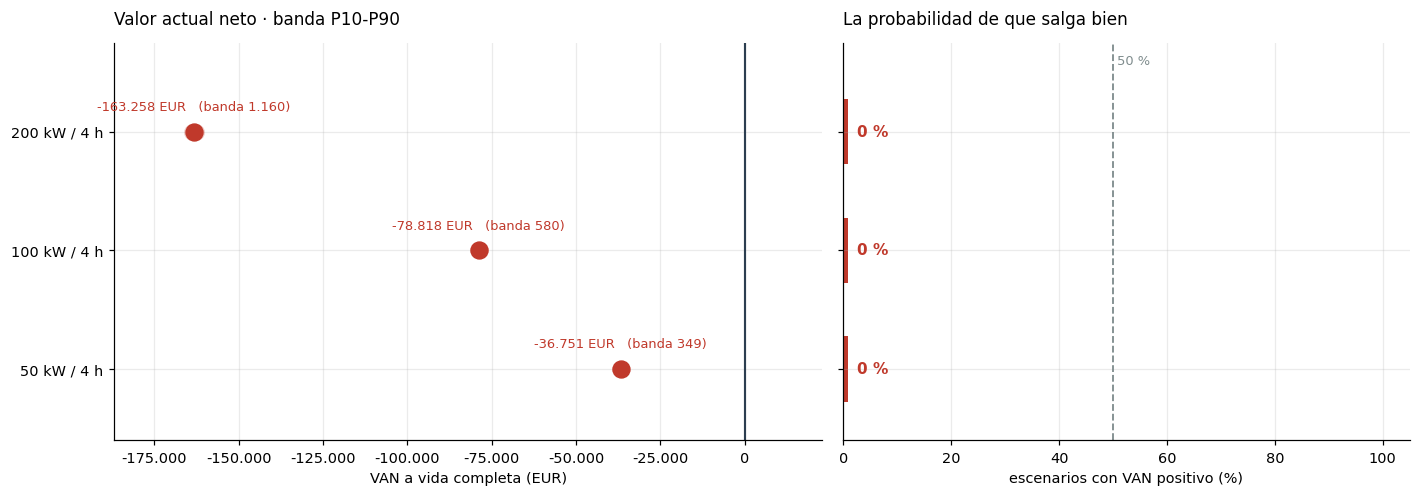

,kW,npv_p10,npv_p50,npv_p90,npv_positive_pct,cycles_per_day,capex_coverage_pct
0,50,-36913.2,-36750.8,-36564.0,0.0,0.3,47.2
1,100,-79120.1,-78818.3,-78540.6,0.0,0.3,35.8
2,200,-163888.7,-163257.8,-162728.9,0.0,0.2,29.5


In [13]:
d = pd.read_sql("""
    SELECT c.code, c.name, b.power_mw, b.duration_h,
           r.npv_p10, r.npv_p50, r.npv_p90, r.npv_positive_pct,
           r.cycles_per_day, r.margin_annual_mean, r.capex_coverage_pct, r.life_years
    FROM app_case_run r
    JOIN app_study_case c ON c.case_id = r.case_id
    JOIN app_battery_model b ON b.battery_id = c.battery_id
    JOIN app_user u ON u.user_id = c.user_id
    WHERE u.email = %(e)s AND c.code LIKE 'DIM-%%'
    ORDER BY b.power_mw""", con, params={"e": os.environ["TFM_EMAIL"]})

if d.empty:
    print("  no hay casos DIM-* ejecutados todavia")
else:
    fig, ax = plt.subplots(1, 2, figsize=(13, 4.6),
                           gridspec_kw={"width_ratios": [1.25, 1]})
    kw = (d.power_mw * 1000).astype(int)
    y = np.arange(len(d))

    # el abanico: la banda P10-P90 y la mediana
    for i, r_ in d.iterrows():
        col = VERDE if r_.npv_p50 > 0 else ROJO
        ax[0].plot([r_.npv_p10, r_.npv_p90], [i, i], lw=11, color=col, alpha=.28,
                   solid_capstyle="round")
        ax[0].plot(r_.npv_p50, i, "o", ms=11, color=col, zorder=3)
        banda = r_.npv_p90 - r_.npv_p10
        ax[0].annotate(f"{r_.npv_p50:,.0f} EUR".replace(",", ".") +
                       f"   (banda {banda:,.0f})".replace(",", "."),
                       (r_.npv_p50, i), textcoords="offset points", xytext=(0, 14),
                       ha="center", fontsize=8.5, color=col)
    ax[0].axvline(0, color="#2c3e50", lw=1.4)
    ax[0].set_yticks(y); ax[0].set_yticklabels([f"{k} kW / 4 h" for k in kw])
    ax[0].set_ylim(-.6, len(d) - .25)          # sitio para las etiquetas de arriba
    ax[0].set_xlabel("VAN a vida completa (EUR)"); ax[0].xaxis.set_major_formatter(eur)
    ax[0].margins(x=.14)
    ax[0].set_title("Valor actual neto · banda P10-P90", fontsize=11, loc="left", pad=12)

    # el porcentaje de escenarios positivos, que es EL numero
    col = [VERDE if v >= 50 else (NARA if v >= 20 else ROJO) for v in d.npv_positive_pct]
    ax[1].barh(y, np.maximum(d.npv_positive_pct, .8), color=col, height=.55)
    ax[1].axvline(50, color=GRIS, ls="--", lw=1.2)
    ax[1].text(50, len(d) - .35, " 50 %", color=GRIS, fontsize=8.5, va="top")
    for i, v in enumerate(d.npv_positive_pct):
        ax[1].text(max(v, 0) + 2.5, i, f"{v:.0f} %", va="center", fontsize=10,
                   color=col[i], weight="bold")
    ax[1].set_yticks(y); ax[1].set_yticklabels([]); ax[1].set_xlim(0, 105)
    ax[1].set_ylim(-.6, len(d) - .25)
    ax[1].set_xlabel("escenarios con VAN positivo (%)")
    ax[1].set_title("La probabilidad de que salga bien", fontsize=11, loc="left", pad=12)
    plt.tight_layout(); plt.show()

    display(d.assign(kW=kw)[["kW", "npv_p10", "npv_p50", "npv_p90", "npv_positive_pct",
                             "cycles_per_day", "capex_coverage_pct"]].round(1))

### 2 · ¿Cuánto gano y cuándo?

El margen año a año con su banda. **El color distingue el tramo histórico del simulado**: en
lo ya ocurrido no hay banda porque el precio fue el que fue, y fingir incertidumbre ahí sería
inventarla. Es un detalle que un tribunal mira.

C:\Users\torgi\AppData\Local\Temp\ipykernel_36284\333559932.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  a = pd.read_sql("""


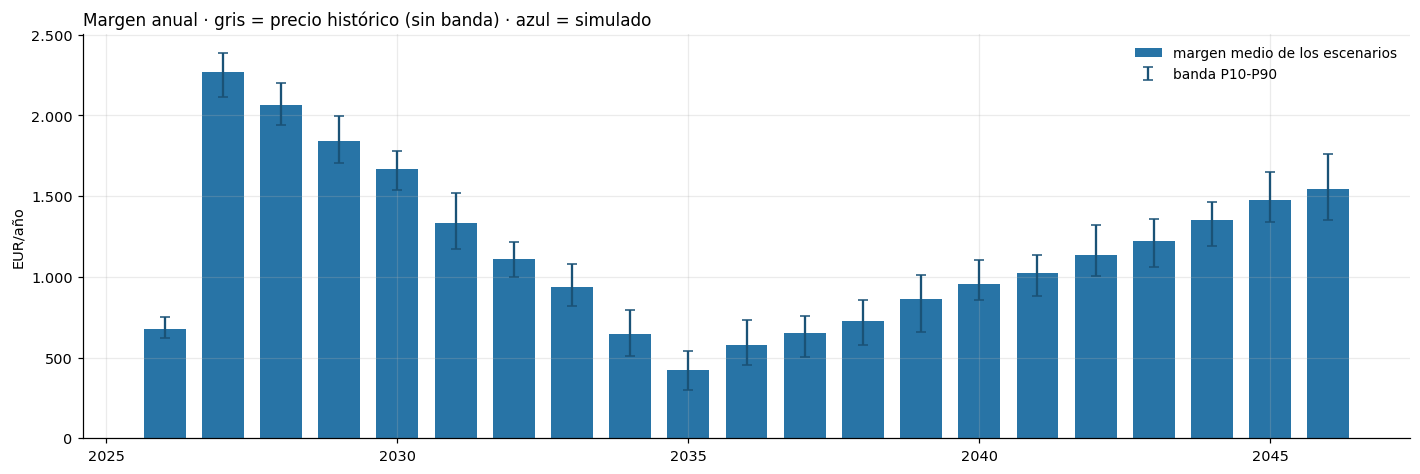

  el margen cae hasta 2035 y luego se recupera: es el hueco de mediodia hundiendose y el pico de tarde aguantando


In [14]:
a = pd.read_sql("""
    SELECT c.code, a.year, a.origin, a.days, a.margin_mean,
           a.p10 AS margin_p10, a.p50 AS margin_p50, a.p90 AS margin_p90,
           a.cycles_per_day
    FROM app_case_result_annual a
    JOIN app_case_run r ON r.run_id = a.run_id
    JOIN app_study_case c ON c.case_id = r.case_id
    JOIN app_user u ON u.user_id = c.user_id
    WHERE u.email = %(e)s AND c.code = 'DIM-100'
    ORDER BY a.year""", con, params={"e": os.environ["TFM_EMAIL"]})

if a.empty:
    print("  DIM-100 todavia no ha terminado")
else:
    fig, ax = plt.subplots(figsize=(13, 4.4))
    col = np.where(a.origin == "simulado", AZUL, GRIS)
    ax.bar(a.year, a.margin_mean, color=col, width=.72,
           label="margen medio de los escenarios")
    sim = a.origin == "simulado"
    ax.errorbar(a.year[sim], a.margin_p50[sim],
                yerr=[a.margin_p50[sim] - a.margin_p10[sim],
                      a.margin_p90[sim] - a.margin_p50[sim]],
                fmt="none", ecolor="#1a5276", elinewidth=1.5, capsize=3.5,
                label="banda P10-P90")
    ax.set_ylabel("EUR/año"); ax.yaxis.set_major_formatter(eur)
    ax.set_title("Margen anual · gris = precio histórico (sin banda) · azul = simulado",
                 fontsize=11, loc="left")
    ax.legend(frameon=False, fontsize=9)
    plt.tight_layout(); plt.show()
    print(f"  el margen cae hasta {a.loc[a.margin_mean.idxmin(), 'year']} y luego se "
          f"recupera: es el hueco de mediodia hundiendose y el pico de tarde aguantando")

### 3 · ¿Qué hace exactamente la batería?

Una semana, hora a hora. **Las bandas de carga y descarga ocupan todo el eje vertical** a
propósito: pintarlas proporcionales al precio las hace invisibles justo cuando el precio se va
a cero, que es cuando más carga. Es el error más fácil de cometer en esta gráfica.

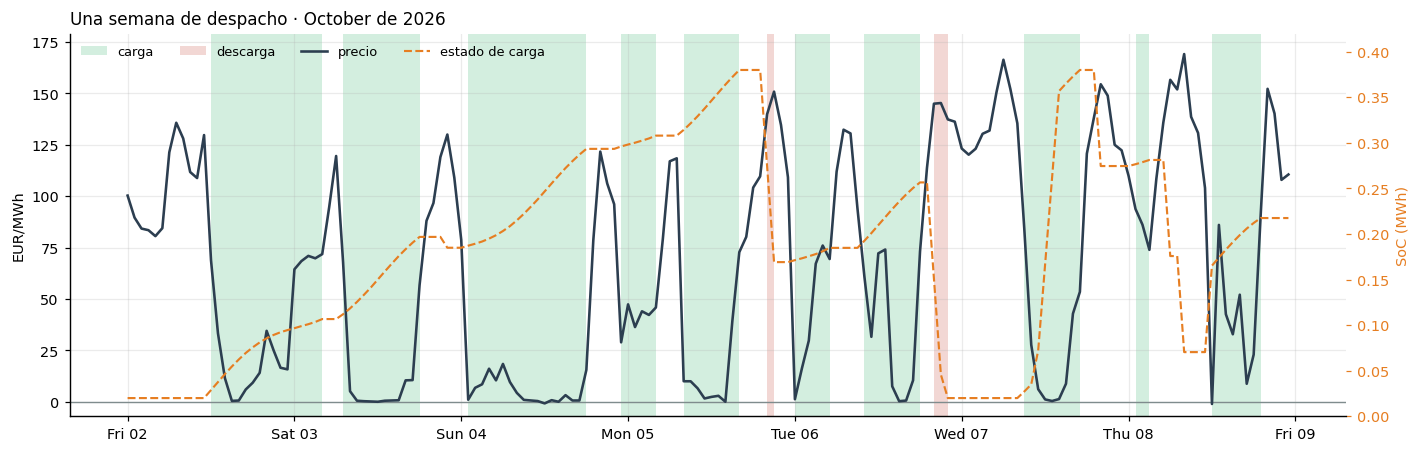

In [15]:
def semana(inicio=30, ndias=7, ax=None):
    """Siete dias de despacho. El fondo dice que hace la bateria; la linea, el precio."""
    sl = slice(inicio, inicio + ndias)
    ts = pd.to_datetime(np.repeat(fechas[sl].to_numpy(), 24)
                        + np.tile(np.arange(24) * np.timedelta64(1, "h"), ndias))
    p = det["precio"][sl].ravel()
    c, dd = det["carga"][sl].ravel(), det["descarga"][sl].ravel()
    soc = det["soc"][sl].ravel()

    if ax is None:
        _, ax = plt.subplots(figsize=(13, 4.2))
    lo, hi = min(p.min(), 0) - 6, p.max() + 10
    # el fondo cubre TODO el eje: a precio cero el verde tiene que verse igual
    ax.fill_between(ts, lo, hi, where=c > 1e-6, color=VERDE, alpha=.20, lw=0, step="mid",
                    label="carga")
    ax.fill_between(ts, lo, hi, where=dd > 1e-6, color=ROJO, alpha=.20, lw=0, step="mid",
                    label="descarga")
    ax.plot(ts, p, color="#2c3e50", lw=1.7, label="precio", zorder=3)
    ax.axhline(0, color=GRIS, lw=.9)
    ax.set_ylim(lo, hi); ax.set_ylabel("EUR/MWh")
    ax2 = ax.twinx()
    ax2.plot(ts, soc, color=NARA, lw=1.4, ls="--", label="estado de carga", zorder=4)
    ax2.set_ylim(0, bat["potencia_mw"] * bat["duracion_h"] * 1.05)
    ax2.set_ylabel("SoC (MWh)", color=NARA); ax2.grid(False)
    ax2.tick_params(axis="y", colors=NARA)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%a %d"))
    h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, ncol=4, frameon=False, fontsize=8.5, loc="upper left")
    return ax

ax = semana(30)
ax.set_title(f"Una semana de despacho · {fechas[30]:%B de %Y}", fontsize=11, loc="left")
plt.tight_layout(); plt.show()

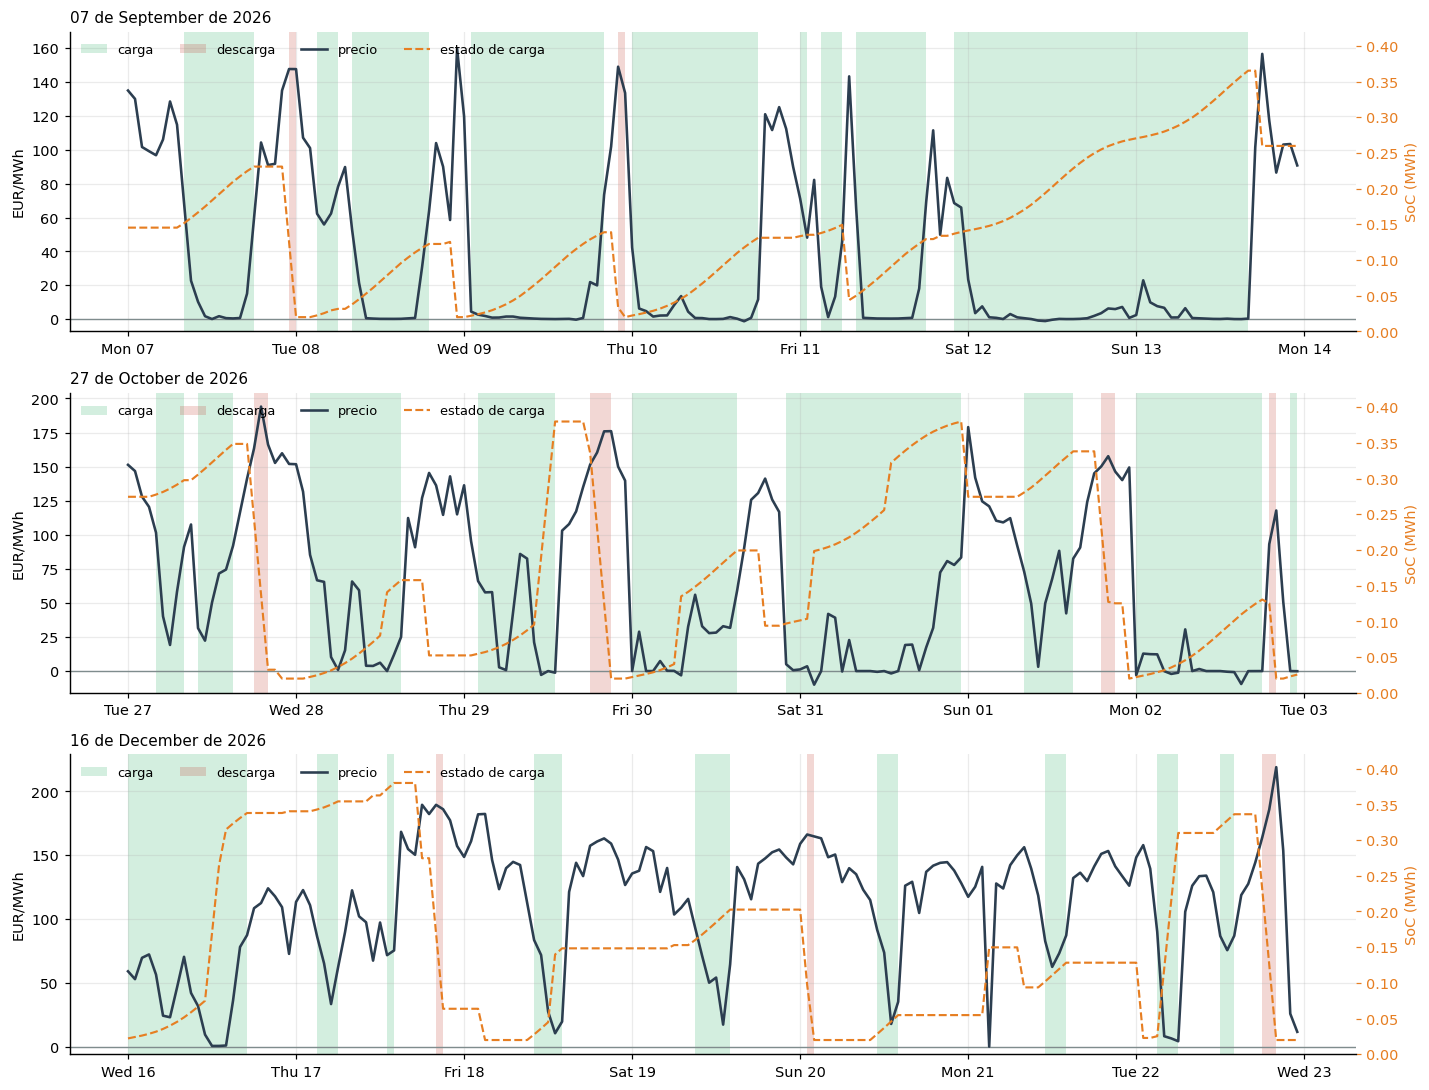

In [16]:
# tres muestras separadas en el año, que es como se ve que el patron cambia con la estacion
fig, axes = plt.subplots(3, 1, figsize=(13, 10))
for ax_, ini in zip(axes, (5, 55, 105)):
    semana(ini, ax=ax_)
    ax_.set_title(f"{fechas[ini]:%d de %B de %Y}", fontsize=10, loc="left")
plt.tight_layout(); plt.show()

### 4 · ¿Y un día normal?

El perfil medio por estación. Es lo que contesta *"¿cuándo carga y cuándo descarga mi
batería?"* sin obligar a leer una semana entera.

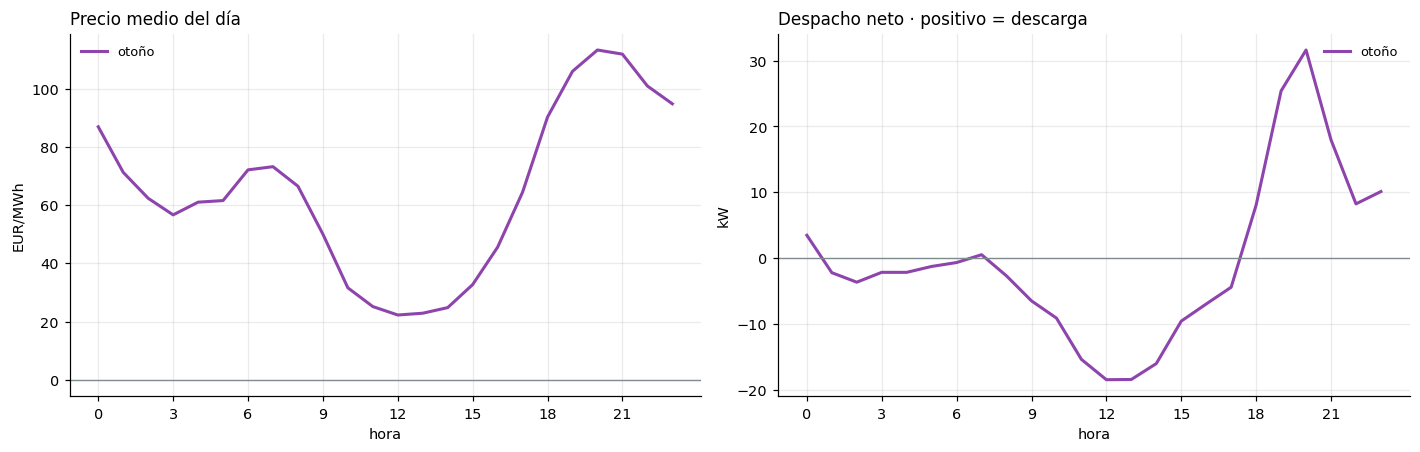

In [17]:
est = pd.cut(fechas.month, [0, 2, 5, 8, 11, 12],
             labels=["invierno", "primavera", "verano", "otoño", "invierno "],
             ordered=False)
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
for e, col in zip(["invierno", "primavera", "verano", "otoño"],
                  [AZUL, VERDE, NARA, MORA]):
    m = np.asarray(est == e)
    if m.sum() < 5:
        continue
    ax[0].plot(range(24), det["precio"][m].mean(axis=0), lw=2, color=col, label=e)
    neto = (det["descarga"][m] - det["carga"][m]).mean(axis=0)
    ax[1].plot(range(24), neto * 1000, lw=2, color=col, label=e)
ax[0].axhline(0, color=GRIS, lw=.9); ax[1].axhline(0, color=GRIS, lw=.9)
ax[0].set_title("Precio medio del día", fontsize=11, loc="left")
ax[1].set_title("Despacho neto · positivo = descarga", fontsize=11, loc="left")
for a_ in ax:
    a_.set_xticks(range(0, 24, 3)); a_.set_xlabel("hora"); a_.legend(frameon=False, fontsize=8.5)
ax[0].set_ylabel("EUR/MWh"); ax[1].set_ylabel("kW")
plt.tight_layout(); plt.show()

### 5 · ¿De dónde sale el dinero?

La cascada. Del CAPEX al VAN, pasando por lo que se ingresa, lo que cuesta el desgaste y lo
que se lleva el OPEX. **Es la gráfica que explica un VAN negativo** sin que haya que
creérselo: se ve qué partida se lo come.

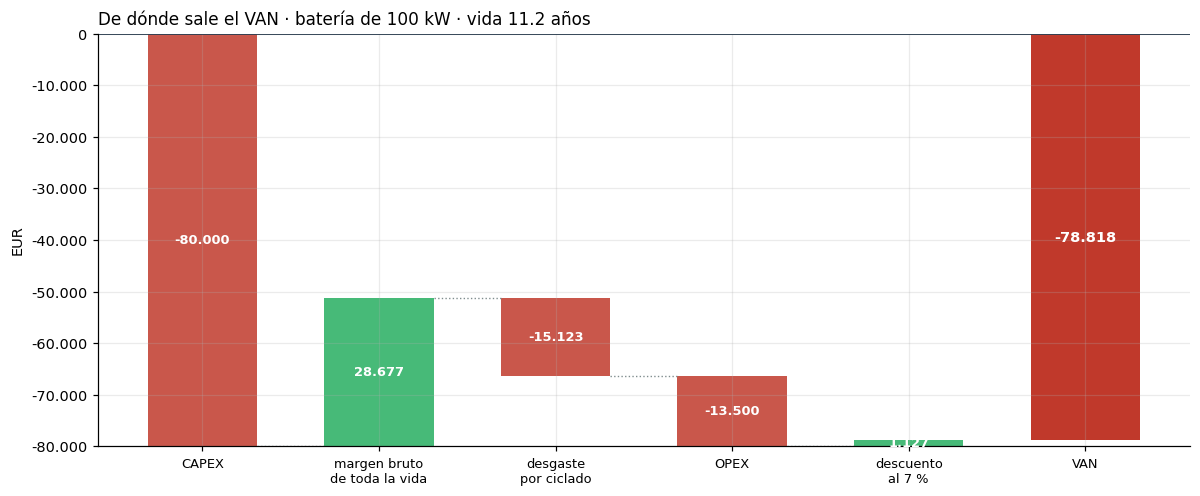

In [18]:
if not d.empty:
    r_ = d.iloc[1] if len(d) > 1 else d.iloc[0]
    E_tot = r_.power_mw * r_.duration_h
    capex = E_tot * 200_000
    vida = float(r_.life_years)
    ingreso = float(r_.margin_annual_mean) * r_.power_mw * vida   # bruto de vida
    desgaste = coste_ciclo(dict(BATERIA, potencia_mw=r_.power_mw,
                                duracion_h=r_.duration_h)) * \
               float(r_.cycles_per_day) * 365 * vida * E_tot * .9
    opex = capex * 0.015 * vida
    van = float(r_.npv_p50)

    pasos = [("CAPEX", -capex), ("margen bruto\nde toda la vida", ingreso + desgaste),
             ("desgaste\npor ciclado", -desgaste), ("OPEX", -opex),
             ("descuento\nal 7 %", van - (-capex + ingreso - opex))]
    fig, ax = plt.subplots(figsize=(11, 4.6))
    acum = 0.0
    for i, (nom, v) in enumerate(pasos):
        col = VERDE if v > 0 else ROJO
        ax.bar(i, v, bottom=acum, color=col, alpha=.85, width=.62)
        ax.text(i, acum + v / 2, f"{v:,.0f}".replace(",", "."), ha="center",
                va="center", fontsize=8.5, color="white", weight="bold")
        acum += v
        if i < len(pasos) - 1:
            ax.plot([i + .31, i + .69], [acum, acum], color=GRIS, lw=.9, ls=":")
    ax.bar(len(pasos), acum, color=VERDE if acum > 0 else ROJO, width=.62)
    ax.text(len(pasos), acum / 2, f"{acum:,.0f}".replace(",", "."), ha="center",
            va="center", fontsize=9.5, color="white", weight="bold")
    ax.set_xticks(range(len(pasos) + 1))
    ax.set_xticklabels([p[0] for p in pasos] + ["VAN"], fontsize=8.5)
    ax.axhline(0, color="#2c3e50", lw=1.2)
    ax.set_ylabel("EUR"); ax.yaxis.set_major_formatter(eur)
    ax.set_title(f"De dónde sale el VAN · batería de {r_.power_mw*1000:.0f} kW · "
                 f"vida {vida:.1f} años", fontsize=11, loc="left")
    plt.tight_layout(); plt.show()

### 6 · ¿Me sobra o me falta batería?

**El diagnóstico de dimensionado, y la gráfica que más dinero ahorra.** `cycles_per_day` por
debajo de 0,5 significa que se ha pagado potencia que no se usa. Y el barrido de tamaños
enseña dónde está el óptimo, que casi nunca es "la más grande que quepa".

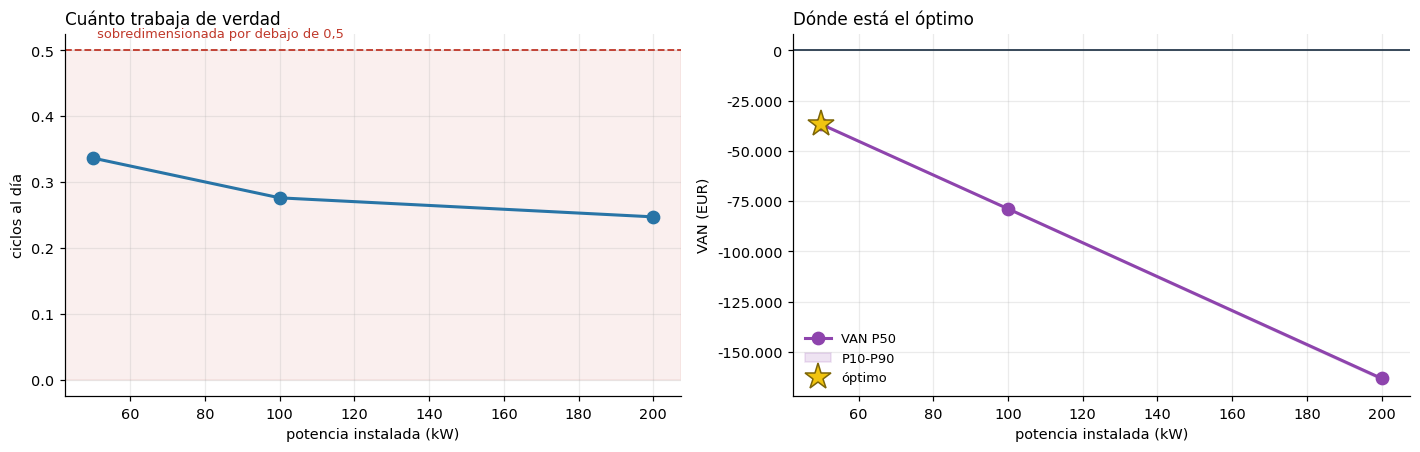

  el mejor de los probados: 50 kW · VAN -36.751 EUR


In [19]:
if not d.empty and len(d) > 1:
    fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
    kw = (d.power_mw * 1000).astype(int)

    ax[0].plot(kw, d.cycles_per_day, "o-", color=AZUL, lw=2, ms=8)
    ax[0].axhspan(0, 0.5, color=ROJO, alpha=.08)
    ax[0].axhline(0.5, color=ROJO, ls="--", lw=1.2)
    ax[0].text(kw.iloc[0], 0.52, " sobredimensionada por debajo de 0,5",
               color=ROJO, fontsize=8.5)
    ax[0].set_xlabel("potencia instalada (kW)"); ax[0].set_ylabel("ciclos al día")
    ax[0].set_title("Cuánto trabaja de verdad", fontsize=11, loc="left")

    ax[1].plot(kw, d.npv_p50, "o-", color=MORA, lw=2, ms=8, label="VAN P50")
    ax[1].fill_between(kw, d.npv_p10, d.npv_p90, color=MORA, alpha=.15, label="P10-P90")
    ax[1].axhline(0, color="#2c3e50", lw=1.2)
    mejor = d.npv_p50.idxmax()
    ax[1].plot(kw[mejor], d.npv_p50[mejor], "*", ms=18, color=AMAR,
               markeredgecolor="#7d6608", zorder=5, label="óptimo")
    ax[1].set_xlabel("potencia instalada (kW)"); ax[1].set_ylabel("VAN (EUR)")
    ax[1].yaxis.set_major_formatter(eur)
    ax[1].set_title("Dónde está el óptimo", fontsize=11, loc="left")
    ax[1].legend(frameon=False, fontsize=8.5)
    plt.tight_layout(); plt.show()
    print(f"  el mejor de los probados: {kw[mejor]} kW · "
          f"VAN {d.npv_p50[mejor]:,.0f} EUR".replace(",", "."))

### 6b · ¿Y qué haría falta para que saliera?

**La gráfica más útil de todas cuando la respuesta es que no**, y es la que hay que enseñar
justo después de un VAN negativo. Decirle a alguien "no te sale" sin decirle *por cuánto* ni
*qué tendría que cambiar* es inútil.

Se barre el CAPEX, se recalcula el coste de ciclo —que depende de él— y **se vuelve a
optimizar**, porque una batería más barata cicla más: con menos desgaste que pagar, al
optimizador le compensan huecos de precio que antes descartaba. Por eso no vale con dividir.

**Sobre el horizonte entero, no sobre los 120 días de las gráficas anteriores.** Los primeros
meses de la curva son de precio alto y anualizarlos sale un 40 % por encima de la realidad: el
hueco de precios de mediados de los treinta se queda fuera. Cuesta un minuto más de cálculo y
es la diferencia entre un número que cuadra con el caso guardado y otro que no.

  horizonte 2026-09-02 -> 2046-12-31 · 7.426 dias


      200k EUR/MWh · ciclo  37.0 · 0.27 ciclos/dia · VAN    -79.049


      150k EUR/MWh · ciclo  27.8 · 0.40 ciclos/dia · VAN    -51.357


      110k EUR/MWh · ciclo  20.4 · 0.52 ciclos/dia · VAN    -27.892


       80k EUR/MWh · ciclo  14.8 · 0.60 ciclos/dia · VAN     -9.552


       55k EUR/MWh · ciclo  10.2 · 0.66 ciclos/dia · VAN      6.147


       35k EUR/MWh · ciclo   6.5 · 0.70 ciclos/dia · VAN     18.941


,capex_eur_mwh,capex_total,coste_ciclo,ciclos_dia,ahorro_anual,vida,van
0,200000,80000.0,37.0,0.3,1205.1,25.0,-79048.9
1,150000,60000.0,27.8,0.4,1611.7,25.0,-51356.9
2,110000,44000.0,20.4,0.5,2060.6,25.0,-27891.7
3,80000,32000.0,14.8,0.6,2469.7,25.0,-9552.5
4,55000,22000.0,10.2,0.7,2852.2,25.0,6146.7
5,35000,14000.0,6.5,0.7,3181.5,23.6,18941.0


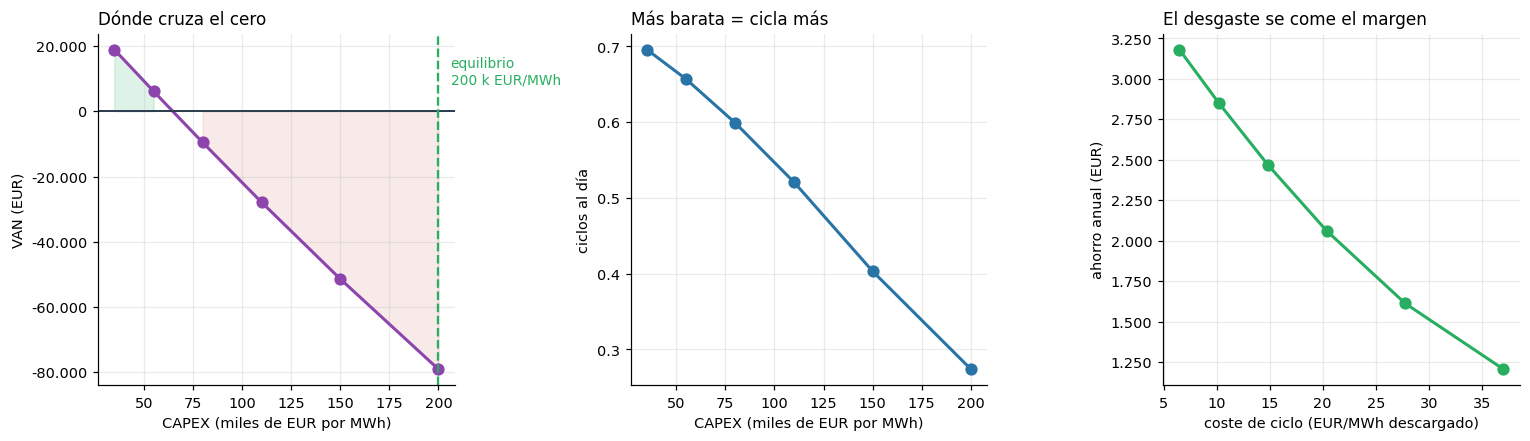

  hoy. a 200k EUR/MWh: coste de ciclo 37.0 EUR/MWh · 0.27 ciclos/dia · VAN -79.049 EUR
  saldria a partir de 200k EUR/MWh, un 0% por debajo del precio de hoy


In [20]:
CAPEX_BARRIDO = [200_000, 150_000, 110_000, 80_000, 55_000, 35_000]
TASA, OPEX = 0.07, 0.015
E_dem = bat["potencia_mw"] * bat["duracion_h"]
e_util = E_dem * (bat["soc_max"] - bat["soc_min"])

# `px_t`, `L_t` y `G_t` son los del horizonte entero, montados en la seccion 6 desde las
# mismas tablas que lee `caso.py`. Nada nuevo aqui: solo se cambia el CAPEX.
base_t = sin_bateria(px_t, L_t, G_t, sitio=sitio)
print(f"  horizonte {dias_curva[0]:%Y-%m-%d} -> {dias_curva[-1]:%Y-%m-%d} · "
      f"{len(px_t):,} dias".replace(",", "."))

fila = []
for cx in CAPEX_BARRIDO:
    b_ = dict(bat, capex_eur_mwh=cx)
    cc_ = coste_ciclo(b_)
    r_ = optimizar(px_t, bat=b_, sitio=sitio, consumo=L_t, generacion=G_t)
    ahorro = (r_.margen_eur - base_t.margen_eur).to_numpy()
    ciclos = float(r_.descarga_mwh.sum() / len(r_) / e_util)
    capex = E_dem * cx
    vida = min(b_["ciclos_vida"] / max(ciclos * 365, 1e-9), 25.0)
    # los flujos AÑO A AÑO, como hace caso.py: la curva no es plana y la bateria no
    # vive veinte años, asi que promediar el horizonte entero falsea el descuento
    por_ano = pd.Series(ahorro).groupby(anos_t).sum()
    completos = pd.Series(anos_t).value_counts().sort_index() >= 365
    flujos = por_ano[completos.to_numpy()].to_numpy()[:int(vida)] - capex * OPEX
    van = -capex + float(np.sum(flujos / (1 + TASA) ** np.arange(1, len(flujos) + 1)))
    fila.append(dict(capex_eur_mwh=cx, capex_total=capex, coste_ciclo=cc_,
                     ciclos_dia=ciclos, ahorro_anual=float(flujos.mean() + capex * OPEX),
                     vida=vida, van=van))
    print(f"    {cx/1000:5.0f}k EUR/MWh · ciclo {cc_:5.1f} · {ciclos:.2f} ciclos/dia "
          f"· VAN {van:>10,.0f}".replace(",", "."))

bar = pd.DataFrame(fila)
display(bar.round(1))

# el CAPEX de equilibrio, interpolando donde el VAN cruza cero
x, yv = bar.capex_eur_mwh.to_numpy()[::-1], bar.van.to_numpy()[::-1]
equil = float(np.interp(0.0, yv, x)) if yv.min() < 0 < yv.max() else np.nan

fig, ax = plt.subplots(1, 3, figsize=(14, 4.1))
ax[0].plot(bar.capex_eur_mwh / 1000, bar.van, "o-", color=MORA, lw=2, ms=7)
ax[0].axhline(0, color="#2c3e50", lw=1.3)
if np.isfinite(equil):
    ax[0].axvline(equil / 1000, color=VERDE, ls="--", lw=1.5)
    ax[0].annotate(f"equilibrio\n{equil/1000:.0f} k EUR/MWh", (equil / 1000, 0),
                   textcoords="offset points", xytext=(8, 18), color=VERDE, fontsize=9)
ax[0].fill_between(bar.capex_eur_mwh / 1000, bar.van, 0,
                   where=bar.van > 0, color=VERDE, alpha=.15)
ax[0].fill_between(bar.capex_eur_mwh / 1000, bar.van, 0,
                   where=bar.van <= 0, color=ROJO, alpha=.10)
ax[0].set_xlabel("CAPEX (miles de EUR por MWh)"); ax[0].set_ylabel("VAN (EUR)")
ax[0].yaxis.set_major_formatter(eur)
ax[0].set_title("Dónde cruza el cero", fontsize=11, loc="left")

ax[1].plot(bar.capex_eur_mwh / 1000, bar.ciclos_dia, "o-", color=AZUL, lw=2, ms=7)
ax[1].set_xlabel("CAPEX (miles de EUR por MWh)"); ax[1].set_ylabel("ciclos al día")
ax[1].set_title("Más barata = cicla más", fontsize=11, loc="left")

ax[2].plot(bar.coste_ciclo, bar.ahorro_anual, "o-", color=VERDE, lw=2, ms=7)
ax[2].set_xlabel("coste de ciclo (EUR/MWh descargado)")
ax[2].set_ylabel("ahorro anual (EUR)"); ax[2].yaxis.set_major_formatter(eur)
ax[2].set_title("El desgaste se come el margen", fontsize=11, loc="left")
plt.tight_layout(); plt.show()

hoy = bar.iloc[0]
print(f"  hoy, a {hoy.capex_eur_mwh/1000:.0f}k EUR/MWh: coste de ciclo "
      f"{hoy.coste_ciclo:.1f} EUR/MWh · {hoy.ciclos_dia:.2f} ciclos/dia · "
      f"VAN {hoy.van:,.0f} EUR".replace(",", "."))
if np.isfinite(equil):
    print(f"  saldria a partir de {equil/1000:.0f}k EUR/MWh, un "
          f"{(1 - equil/200_000):.0%} por debajo del precio de hoy")
else:
    print(f"  no cruza el cero en el rango probado: no es un problema de precio de bateria")

**Los tres paneles dicen lo mismo desde tres sitios.** El desgaste por ciclado —37 €/MWh
descargado con la batería a 200.000 €/MWh— se lleva casi todo el diferencial que hay entre el
valle y el pico. Por eso cicla tan poco: al optimizador no le compensa. Al bajar el CAPEX baja
el coste de ciclo, aparecen huecos que antes no valían la pena, y el ahorro sube **más que
proporcionalmente**. Es el argumento contra dividir el VAN entre dos para estimar una batería
que cuesta la mitad.

### 7 · ¿Cómo queda mi factura?

Solo tiene sentido en **autoconsumo**, y es lo que de verdad le interesa a quien tiene una
fábrica: no el margen de arbitraje, sino cuánto baja la factura.

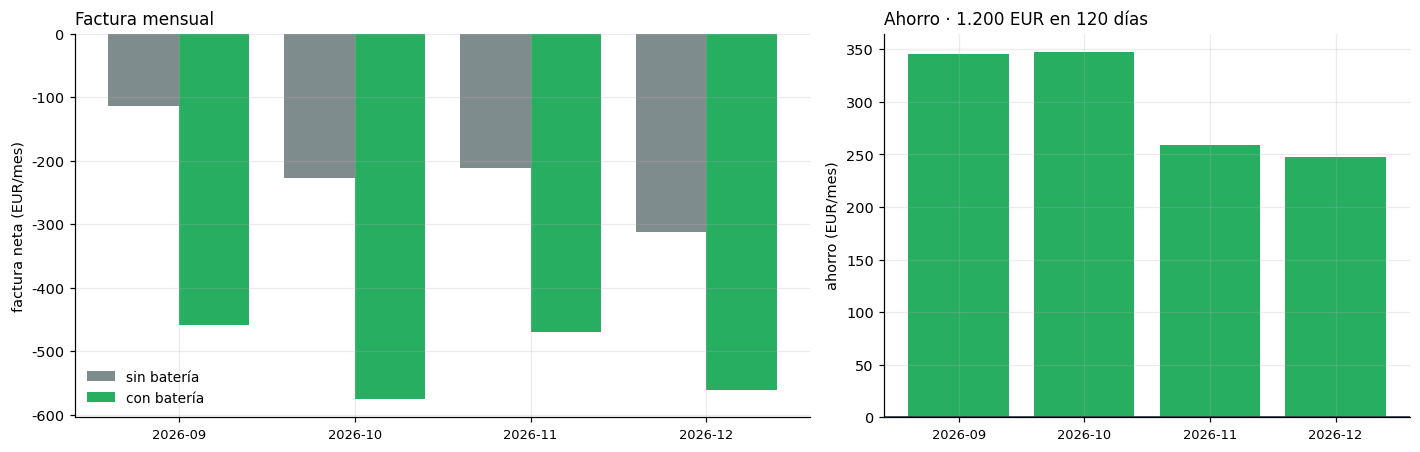

In [21]:
mes = pd.PeriodIndex(fechas, freq="M")
comp = pd.DataFrame({
    "mes": mes,
    "sin": base.compra_eur.to_numpy() - base.venta_eur.to_numpy(),
    "con": res.compra_eur.to_numpy() - res.venta_eur.to_numpy(),
}).groupby("mes").sum()
comp["ahorro"] = comp["sin"] - comp["con"]

fig, ax = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw={"width_ratios": [1.4, 1]})
x = np.arange(len(comp))
ax[0].bar(x - .2, comp["sin"], width=.4, color=GRIS, label="sin batería")
ax[0].bar(x + .2, comp["con"], width=.4, color=VERDE, label="con batería")
ax[0].set_xticks(x); ax[0].set_xticklabels([str(p) for p in comp.index], fontsize=8.5)
ax[0].set_ylabel("factura neta (EUR/mes)"); ax[0].yaxis.set_major_formatter(eur)
ax[0].legend(frameon=False, fontsize=9)
ax[0].set_title("Factura mensual", fontsize=11, loc="left")

ax[1].bar(x, comp["ahorro"], color=[VERDE if v > 0 else ROJO for v in comp["ahorro"]])
ax[1].axhline(0, color="#2c3e50", lw=1.1)
ax[1].set_xticks(x); ax[1].set_xticklabels([str(p) for p in comp.index], fontsize=8.5)
ax[1].set_ylabel("ahorro (EUR/mes)")
ax[1].set_title(f"Ahorro · {comp.ahorro.sum():,.0f} EUR en {N_DIAS} días"
                .replace(",", "."), fontsize=11, loc="left")
plt.tight_layout(); plt.show()

### 8 · ¿Cómo es mi instalación?

La vista que hay que enseñar **justo después de subir los ficheros**, antes de optimizar nada.
Si el consumo o la generación están mal cargados, se ve aquí — y no tres minutos después.

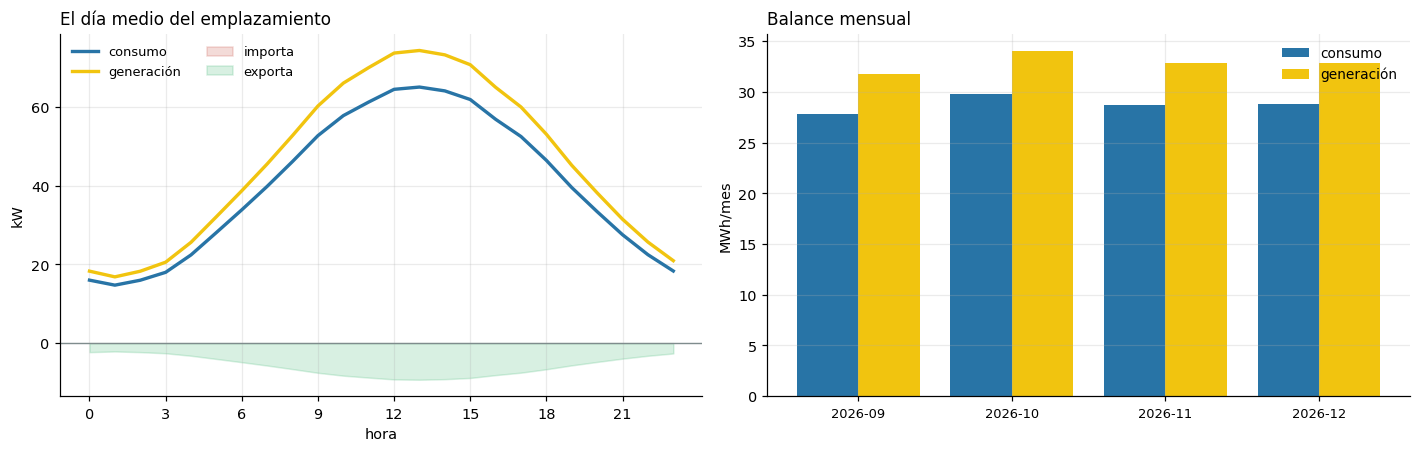

  la generación cubre directamente el 100% del consumo · excedente 16.4 MWh en 120 días


In [22]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
ax[0].plot(range(24), L.mean(axis=0) * 1000, lw=2.2, color=AZUL, label="consumo")
ax[0].plot(range(24), G.mean(axis=0) * 1000, lw=2.2, color=AMAR, label="generación")
neto = (L - G).mean(axis=0) * 1000
ax[0].fill_between(range(24), 0, neto, where=neto > 0, color=ROJO, alpha=.18,
                   label="importa")
ax[0].fill_between(range(24), 0, neto, where=neto < 0, color=VERDE, alpha=.18,
                   label="exporta")
ax[0].axhline(0, color=GRIS, lw=.9)
ax[0].set_xticks(range(0, 24, 3)); ax[0].set_xlabel("hora"); ax[0].set_ylabel("kW")
ax[0].legend(frameon=False, fontsize=8.5, ncol=2)
ax[0].set_title("El día medio del emplazamiento", fontsize=11, loc="left")

m = pd.DataFrame({"mes": mes, "consumo": L.sum(axis=1), "generacion": G.sum(axis=1)}
                 ).groupby("mes").sum()
xm = np.arange(len(m))
ax[1].bar(xm - .2, m.consumo, width=.4, color=AZUL, label="consumo")
ax[1].bar(xm + .2, m.generacion, width=.4, color=AMAR, label="generación")
ax[1].set_xticks(xm); ax[1].set_xticklabels([str(p) for p in m.index], fontsize=8.5)
ax[1].set_ylabel("MWh/mes"); ax[1].legend(frameon=False, fontsize=9)
ax[1].set_title("Balance mensual", fontsize=11, loc="left")
plt.tight_layout(); plt.show()

cob = float(np.minimum(L, G).sum() / L.sum())
print(f"  la generación cubre directamente el {cob:.0%} del consumo · "
      f"excedente {np.maximum(G - L, 0).sum():.1f} MWh en {N_DIAS} días")

---
## 7 · La comprobación contra el servidor

Aquí es donde el notebook deja de documentar y empieza a comprobar. Se manda el formulario de
ejemplo por la misma vía que usará la web y se mira qué contesta.

In [23]:
# el verificador de la cadena entera, que es lo primero que hay que mirar
import subprocess, sys as _s
r = subprocess.run([_s.executable, "production/app/comprobar.py", "--base"],
                   cwd=REPO, capture_output=True, text=True,
                   encoding="utf-8", errors="replace")
print(r.stdout[-3000:])


  comprobacion de la cadena · 2026-08-31
  con base

  ESQUEMA
    ok   las tablas app_* existen                               14 tablas · el codigo usa 10
    ok   cada columna que el codigo escribe existe en su tabla  88 columnas verificadas
    ok   los INSERT literales tienen tantos huecos como columnas 4 literales cuadrados · 9 generados, a salvo por construccion
    ok   los ejes de hora nominal son TIMESTAMP sin zona        2 ejes sin zona
    ok   hay UNA sola curva publicada                           1 fila, como impone el indice unico
  CURVA
    ok   el artefacto abre y cuadra con su meta                 50x178224 · 2026-09-02 -> 2046-12-31 · media 56.2 EUR/MWh
    ok   la rejilla es de 24 horas por dia, sin huecos ni repetidos 7426 dias x 24 h · 41 domingos de cambio de hora, con 24
    ok   no hay hueco entre el ultimo precio conocido y la curva matriz hasta 2026-09-01 -> curva desde 2026-09-02 · sin hueco
    ··   los percentiles de la base son los del .npy
         el .

In [24]:
# y el caso de demostracion, de punta a punta
LANZAR = False        # ponerlo en True para ejecutarlo de verdad (tarda unos minutos)

if not LANZAR:
    print("  LANZAR = False · las ordenes que se ejecutarian:\n")
    for i, x in enumerate(ordenes(FORMULARIO), 1):
        print(f"    {i}. {x}\n")
else:
    for x in ordenes(FORMULARIO):
        print(f"\n$ {x}")
        r = subprocess.run(x.split() if '"' not in x else x, shell='"' in x, cwd=REPO,
                           capture_output=True, text=True, encoding="utf-8",
                           errors="replace")
        print(r.stdout[-1500:])
        if r.returncode:
            print(r.stderr[-1500:])
            break

  LANZAR = False · las ordenes que se ejecutarian:

    1. python production/app/caso.py bateria --code WEB-100KW --nombre "LFP 100 kW / 4 h" --potencia 0.1 --duracion 4

    2. python production/app/caso.py consumo --code WEB-FABRICA --nombre "Fabrica de ejemplo" --fichero "C:\Users\torgi\AppData\Local\Temp\tmp3xszsecf\consumo_ejemplo.csv" --anual 350 --recargo 70

    3. python production/app/caso.py generacion --code WEB-FV --nombre "Cubierta 250 kWp" --mwp 0.25

    4. python production/app/caso.py crear --code WEB-DEMO --nombre "Demo del contrato" --modo autoconsumo --bateria WEB-100KW --consumo WEB-FABRICA --generacion WEB-FV --desde 2026-09-01 --hasta 2046-12-31

    5. python production/app/caso.py ejecutar --code WEB-DEMO --escenarios 20



In [25]:
# lo que la web leeria para pintar la tarjeta de resultado
d = pd.read_sql("SELECT * FROM app_case_summary WHERE email = %(e)s ORDER BY run_at DESC",
                con, params={"e": os.environ["TFM_EMAIL"]})
if d.empty:
    print("  todavia no hay ningun caso ejecutado")
else:
    print(f"  {len(d)} ejecuciones\n")
    display(d[["code", "battery", "power_mw", "duration_h", "consumo", "generacion",
               "margin_annual_mean", "cycles_per_day", "npv_p50",
               "npv_positive_pct"]].round(1))

  4 ejecuciones



C:\Users\torgi\AppData\Local\Temp\ipykernel_36284\3288542513.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  d = pd.read_sql("SELECT * FROM app_case_summary WHERE email = %(e)s ORDER BY run_at DESC",


,code,battery,power_mw,duration_h,consumo,generacion,margin_annual_mean,cycles_per_day,npv_p50,npv_positive_pct
0,DIM-200,LFP-200KW,0.2,4.0,FABRICA,FV-250,8499.2,0.2,-163257.8,0.0
1,DIM-100,LFP-100KW,0.1,4.0,FABRICA,FV-250,12048.6,0.3,-78818.3,0.0
2,DIM-50,LFP-50KW,0.0,4.0,FABRICA,FV-250,18725.2,0.3,-36750.8,0.0
3,EST-01,LFP-4H,1.0,4.0,FABRICA,FV-250,2666.0,0.1,-850717.3,0.0


---
## 8 · Las plantillas que se descargan de la web

El usuario no sabe qué formato tiene que subir. **Que se lo descargue relleno** es la forma
más barata de evitar la mitad de las incidencias: se baja la plantilla, sustituye los números
por los suyos y la vuelve a subir.

Se generan cuatro ficheros, dos por instalación:

| fichero | formato | para quién |
|---|---|---|
| `plantilla_consumo.csv` | largo: `fecha, hora, consumo_kwh` | el que exporta de un sistema de medida |
| `plantilla_consumo.xlsx` | ancho: `fecha` + `H1..H25` | el que trabaja con Excel, que son casi todos |
| `plantilla_generacion.csv` | largo | ídem |
| `plantilla_generacion.xlsx` | ancho | ídem |

**Los cuatro llevan el año 2027 completo, con sus días raros de verdad**: el domingo de marzo
con 23 horas y el de octubre con 25. No es un detalle decorativo — es lo que permite que el
usuario vea cómo se rellenan esos dos días en lugar de inventárselo. El `.xlsx` lleva además
una hoja de instrucciones.

**La unidad va en el nombre de la columna** (`consumo_kwh`), y ese es el sitio donde el
cargador la busca. No se adivina por la magnitud: 40 por hora es 40 kWh en una pyme y 40 MWh
en una fábrica.

In [26]:
PLANT = REPO / "docs" / "plantillas"
PLANT.mkdir(parents=True, exist_ok=True)
ANO_P = 2027

def horas_reales(ano):
    """Los días del año con sus horas españolas: 23 en marzo, 25 en octubre, 24 el resto."""
    out = []
    for dia in pd.date_range(f"{ano}-01-01", f"{ano}-12-31"):
        a = pd.Timestamp(dia).tz_localize("Europe/Madrid", nonexistent="shift_forward")
        b = (pd.Timestamp(dia) + pd.Timedelta(days=1)).tz_localize(
            "Europe/Madrid", nonexistent="shift_forward")
        out.append((dia, round((b - a).total_seconds() / 3600)))
    return out

def perfil_consumo(dia, hora):
    """Fabrica: turno de mañana y tarde, valle de noche, fines de semana al 55 %."""
    est = 1 + 0.22 * np.cos((dia.dayofyear - 20) / 365 * 2 * np.pi)     # invierno alto
    base = 1 + 0.55 * np.exp(-((hora - 11) ** 2) / 12) \
             + 0.40 * np.exp(-((hora - 18) ** 2) / 8)
    finde = 0.55 if dia.dayofweek >= 5 else 1.0
    return 40 * est * base * finde                                       # kWh

def perfil_fv(dia, hora):
    """250 kWp orientados al sur: campana con estacionalidad y algo de nubosidad."""
    est = 0.62 + 0.38 * np.sin((dia.dayofyear - 80) / 365 * 2 * np.pi)
    nube = 0.75 + 0.25 * np.cos(dia.dayofyear * 2.7)                     # determinista
    return max(0.0, 250 * 0.86 * est * nube * np.exp(-((hora - 13.4) ** 2) / 7.5))

def escribir(nombre, perfil, col, titulo, unidad_nota):
    dias = horas_reales(ANO_P)

    # ── largo: fecha, hora, valor ────────────────────────────────────────────
    # la hora ESPAÑOLA (1..25) a la hora del reloj (0..23), con la misma regla que usa el
    # cargador: en octubre las dos veces que se viven las 2:00 son H2 y H3, y en marzo la
    # hora que falta desplaza el resto. Asi la plantilla es coherente con lo que se lee.
    def reloj(h, n):
        if n == 25:
            return h - 1 if h <= 3 else h - 2
        if n == 23:
            return h - 1 if h <= 2 else h
        return h - 1

    filas = [(d.date(), h, round(perfil(d, reloj(h, n)), 2))
             for d, n in dias for h in range(1, n + 1)]
    largo = pd.DataFrame(filas, columns=["fecha", "hora", col])
    largo.to_csv(PLANT / f"{nombre}.csv", index=False)

    # ── ancho: fecha + H1..H25, con las celdas que no existen vacias ─────────
    ancho = largo.pivot_table(index="fecha", columns="hora", values=col)
    ancho.columns = [f"H{c}" for c in ancho.columns]
    ancho = ancho.reindex(columns=[f"H{i}" for i in range(1, 26)])
    ancho.index.name = "fecha"

    INSTR = pd.DataFrame({"instrucciones": [
        titulo, "",
        "COMO SE RELLENA",
        "  Una fila por dia. Las columnas H1..H24 son las horas del dia.",
        f"  Los valores van en {unidad_nota}. La unidad se lee del nombre de la columna",
        "  en el formato largo, o de esta hoja: no cambiar los encabezados.", "",
        "LOS DOS DIAS RAROS DEL AÑO -- ya vienen puestos como ejemplo",
        f"  {[str(d.date()) for d, n in dias if n == 23][0]}  tiene 23 horas: ese domingo",
        "     las 2:00 no existen. Dejar H24 VACIA.",
        f"  {[str(d.date()) for d, n in dias if n == 25][0]}  tiene 25 horas: ese domingo",
        "     las 2:00 se viven dos veces. Rellenar tambien H25.",
        "  Si el fichero trae 24 horas esos dos dias tambien se acepta:",
        "  el cargador lo resuelve, pero avisa.", "",
        "EL AÑO",
        "  La plantilla trae 2027 entero. Sirve cualquier año completo, y",
        "  tambien varios. Si es bisiesto tiene que traer el 29 de febrero.", "",
        "QUE PASA DESPUES",
        "  El fichero da la FORMA de la curva, no su tamaño: el consumo anual",
        "  se pone aparte en el formulario. Asi el mismo perfil vale para una",
        "  instalacion de 200 MWh/año y para otra de 2.000.",
    ]})

    x = PLANT / f"{nombre}.xlsx"
    with pd.ExcelWriter(x, engine="openpyxl") as w:
        INSTR.to_excel(w, sheet_name="instrucciones", index=False)
        ancho.to_excel(w, sheet_name="curva")
    return largo, ancho, dias


lc, ac, dias_p = escribir("plantilla_consumo", perfil_consumo, "consumo_kwh",
                          "PLANTILLA DE CURVA DE CONSUMO", "kWh consumidos en esa hora")
lg, ag, _ = escribir("plantilla_generacion", perfil_fv, "generacion_kwh",
                     "PLANTILLA DE CURVA DE GENERACION", "kWh generados en esa hora")

for p in sorted(PLANT.iterdir()):
    print(f"  {p.name:28s} {p.stat().st_size:>9,} bytes".replace(",", "."))
print(f"\n  {ANO_P}: {len(dias_p)} dias · "
      f"{sum(n for _, n in dias_p):,} horas".replace(",", "."))
print(f"  consumo    {lc.consumo_kwh.sum()/1000:8.1f} MWh/año")
print(f"  generacion {lg.generacion_kwh.sum()/1000:8.1f} MWh/año")

  plantilla_consumo.csv          179.723 bytes
  plantilla_consumo.xlsx          53.099 bytes
  plantilla_generacion.csv       172.303 bytes
  plantilla_generacion.xlsx       50.195 bytes

  2027: 365 dias · 8.760 horas
  consumo       373.9 MWh/año
  generacion    177.1 MWh/año


In [27]:
# los dos dias raros, tal y como quedan en la plantilla ancha
raro23 = [d for d, n in dias_p if n == 23][0]
raro25 = [d for d, n in dias_p if n == 25][0]
print(f"  el domingo de MARZO ({raro23:%d-%m-%Y}) -- 23 horas, H24 vacia:")
display(ac.loc[[raro23.date()], ["H1", "H2", "H3", "H4", "H22", "H23", "H24", "H25"]])
print(f"\n  el domingo de OCTUBRE ({raro25:%d-%m-%Y}) -- 25 horas, H25 rellena:")
display(ac.loc[[raro25.date()], ["H1", "H2", "H3", "H4", "H22", "H23", "H24", "H25"]])
print("\n  un dia normal, para contrastar:")
display(ac.loc[[pd.Timestamp(f"{ANO_P}-06-15").date()],
               ["H1", "H2", "H3", "H4", "H22", "H23", "H24", "H25"]])

  el domingo de MARZO (28-03-2027) -- 23 horas, H24 vacia:


,H1,H2,H3,H4,H22,H23,H24,H25
fecha,,,,,,,,
2027-03-28,23.96,23.97,24.03,24.18,25.26,24.38,NaN,NaN



  el domingo de OCTUBRE (31-10-2027) -- 25 horas, H25 rellena:


,H1,H2,H3,H4,H22,H23,H24,H25
fecha,,,,,,,,
2027-10-31,22.85,22.85,22.86,22.86,28.41,25.82,24.09,23.25



  un dia normal, para contrastar:


,H1,H2,H3,H4,H22,H23,H24,H25
fecha,,,,,,,,
2027-06-15,32.88,32.88,32.9,32.97,37.15,34.66,33.46,NaN


### La vuelta: las plantillas, leídas por el cargador

Las cuatro tienen que volver a salir como una rejilla de 24 h/día. Y las dos de Excel prueban
además **dos casos que se dan con ficheros reales**:

**La hoja no es la primera.** El `.xlsx` lleva las instrucciones delante y la curva detrás. Un
cargador que coja la hoja 0 a ciegas falla con un fichero perfectamente válido, y el error que
suelta —*no reconozco las columnas: ['instrucciones']*— no dice que el problema sea la hoja.
Se prueban todas y se coge la primera que parezca una curva.

**La columna `H25` está siempre puesta**, vacía salvo el domingo de octubre. Es lo normal en
las descargas de distribuidora. Si esas celdas vacías se conservan, los 365 días salen con 25
filas y a todos se les aplica el desplazamiento del cambio de hora — el fichero entero queda
corrido una hora. Una celda vacía es *una hora que no existe*, no un cero.

In [28]:
# la vuelta: las cuatro plantillas releidas. Los .xlsx llevan `unidad` a mano -- ver abajo.
for f_, uni in ((PLANT / "plantilla_consumo.csv", "auto"),
                (PLANT / "plantilla_consumo.xlsx", "kwh"),
                (PLANT / "plantilla_generacion.csv", "auto"),
                (PLANT / "plantilla_generacion.xlsx", "kwh")):
    s_ = cargar(f_, unidad=uni, verbose=False)
    n_ = s_.groupby("dia").size()
    ok = (n_ == 24).all() and len(n_) == 365
    print(f"  {'ok ' if ok else 'MAL'} {f_.name:28s} "
          f"{len(n_)} dias x {sorted(n_.unique())} h · {s_.valor.sum():7.1f} MWh")

  ok  plantilla_consumo.csv        365 dias x [np.int64(24)] h ·   373.9 MWh


  ok  plantilla_consumo.xlsx       365 dias x [np.int64(24)] h ·   373.9 MWh
  ok  plantilla_generacion.csv     365 dias x [np.int64(24)] h ·   177.1 MWh


  ok  plantilla_generacion.xlsx    365 dias x [np.int64(24)] h ·   177.1 MWh


In [29]:
# y el detalle de lo que hace con el Excel, que es donde estan las dos trampas
print("  lo que el cargador cuenta al leer el .xlsx de consumo:\n")
_ = cargar(PLANT / "plantilla_consumo.xlsx", unidad="kwh", verbose=True)

  lo que el cargador cuenta al leer el .xlsx de consumo:

  formato ANCHO: 25 columnas de hora · 365 celdas vacias descartadas
  hoja 'curva'
  horas numeradas 1..25 (convencion española): se pasa a 0..23
     28-03-2027: el calendario tiene 23 horas · cambio de hora de marzo, no existe la 2:00
     31-10-2027: el calendario tiene 25 horas · cambio de hora de octubre, 2A y 2B a la misma hora
  8,760 horas · 365 dias · 2027-01-01 -> 2027-12-31
  1 filas duplicadas promediadas (hora repetida de octubre)
  1 horas ausentes interpoladas dentro de su dia


**Por qué los `.xlsx` llevan la unidad a mano.** En formato ancho las columnas se llaman
`H1..H25`, así que **no hay dónde escribir la unidad**: el CSV largo la lleva en
`consumo_kwh` y el Excel no puede. El cargador lo detecta, avisa y **no adivina** — porque 40
por hora es 40 kWh en una pyme y 40 MWh en una fábrica, y por la magnitud no se distinguen.

Para la web esto es un requisito, no un detalle: **si el fichero subido es ancho, hay que
preguntar la unidad antes de seguir.** Un factor de 1000 sin avisar convierte un estudio en
basura que parece correcta.

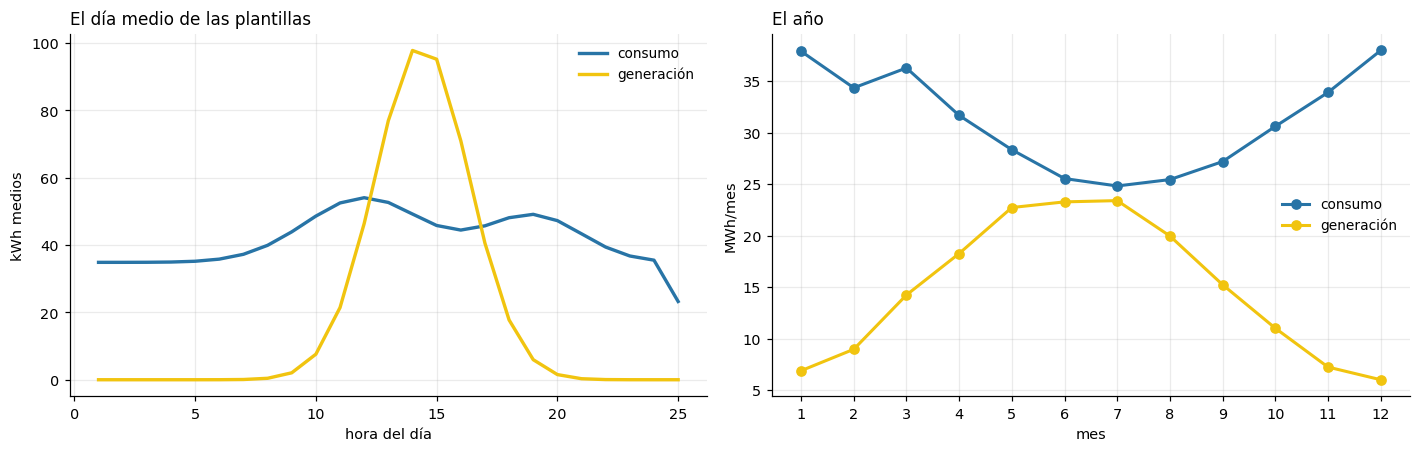

In [30]:
# como se ven las dos plantillas, que es lo que la web enseñara tras la subida
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
for l_, col_, nom, c_ in ((lc, "consumo_kwh", "consumo", AZUL),
                          (lg, "generacion_kwh", "generación", AMAR)):
    per = l_.groupby("hora")[col_].mean()
    ax[0].plot(per.index, per.values, lw=2.2, color=c_, label=nom)
    men = l_.assign(m=pd.to_datetime(l_.fecha).dt.month).groupby("m")[col_].sum() / 1000
    ax[1].plot(men.index, men.values, "o-", lw=2, color=c_, label=nom)
ax[0].set_xlabel("hora del día"); ax[0].set_ylabel("kWh medios")
ax[0].set_title("El día medio de las plantillas", fontsize=11, loc="left")
ax[1].set_xlabel("mes"); ax[1].set_ylabel("MWh/mes"); ax[1].set_xticks(range(1, 13))
ax[1].set_title("El año", fontsize=11, loc="left")
for a_ in ax:
    a_.legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

---
## 9 · El paquete que se le pasa a Magui

Un JSON con el contrato entero, generado desde `CAMPOS`. No hay que copiar nada a mano: se
regenera cuando cambie el motor.

In [31]:
SALIDA = REPO / "docs" / "contrato_web.json"
SALIDA.parent.mkdir(parents=True, exist_ok=True)

contrato = {
    "generado": str(date.today()),
    "curva": {
        "publicada": str(gen), "desde": str(d0), "hasta": str(d1),
        "escenarios": ns, "motor": motor,
        "nota": "UNA sola curva, se pisa cada dia a las 11:45. El usuario no la elige.",
    },
    "pantallas": {
        p: [{k: v for k, v in c.items() if k != "pantalla" and v not in (None, "", 1.0)}
            for c in CAMPOS if c["pantalla"] == p]
        for p in ("bateria", "consumo", "generacion", "caso")
    },
    "formatos_de_fichero": ["ancho: fecha + H1..H24 (o H25 en octubre)",
                            "largo: fecha + hora + valor",
                            "largo: una columna de fecha-hora + valor"],
    "respuesta": {k: [list(x) for x in v] for k, v in RESPUESTA.items()},
    "reglas": [
        "la potencia se enseña en kW y se guarda en MW (factor 0,001)",
        "el CAPEX es por MWh INSTALADO, no total",
        "potencia_minima > 0 convierte el problema en MILP: 20-40x mas lento",
        "modo 'autoconsumo' exige consumo o generacion; 'standalone' no admite ninguno",
        "si el encabezado del fichero no dice la unidad, hay que preguntarla",
        "el numero que va grande es npv_positive_pct, no npv_p50",
    ],
}
SALIDA.write_text(json.dumps(contrato, indent=2, ensure_ascii=False), encoding="utf-8")
print(f"  {SALIDA}")
print(f"  {SALIDA.stat().st_size:,} bytes · {len(CAMPOS)} campos")

  C:\Users\torgi\proyectos\tfm-energia\docs\contrato_web.json
  15,213 bytes · 43 campos


In [32]:
con.rollback()
cur.close()
con.close()
print("  conexion cerrada")

  conexion cerrada


---
## Resumen para Magui

### Lo que hay que construir

**Cuatro pantallas.** Batería, consumo, generación y estudio. Los campos exactos, con su
control, su unidad y su columna de destino, están en la sección 2 y en
`docs/contrato_web.json`, que se regenera desde este notebook.

**Dos subidas de fichero**, con su plantilla descargable al lado. Excel o CSV, cualquiera de
los tres formatos. Las plantillas están en `docs/plantillas/` y **ya traen resueltos los dos
días raros del año**, que es lo que la gente rellena mal.

**Cero campos de precio.** La curva de veinte años ya está, se republica sola cada día a las
11:45 y el usuario no la elige ni la ve como campo.

**Ocho controles obligatorios de verdad.** El resto tiene un valor por defecto sensato y cabe
en *opciones avanzadas*. Merece la pena que la primera pantalla quepa en un móvil.

**Ocho gráficas**, en el orden de la sección 6, que es el orden en que el usuario se hace las
preguntas.

### Las cinco cosas que se hacen mal

1. **Las unidades.** El usuario piensa en kW, la base guarda MW. Factor 0,001, y en `CAMPOS`
   está en qué campos aplica.
2. **El CAPEX es por MWh instalado**, no total. Una de 100 kW / 4 h son 80.000 €, no 200.000.
3. **La unidad del fichero se pregunta** si el encabezado no la trae. No se adivina por la
   magnitud.
4. **Las bandas de carga y descarga ocupan todo el eje vertical.** Proporcionales al precio se
   vuelven invisibles justo cuando el precio se va a cero, que es cuando más carga.
5. **El número grande es `npv_positive_pct`**, no `npv_p50`. Un VAN mediano positivo con un
   45 % de escenarios buenos es una inversión que falla más de la mitad de las veces.

### Lo que queda fuera de este notebook

No hay API: la web llama hoy a `caso.py` por línea de órdenes. Ponerle una capa HTTP encima es
directo —el contrato ya está cerrado y validado— pero mientras tanto las cuatro órdenes de la
sección 4 son la interfaz real.